# Sales Analytics & Prediction

## Project Objective

The objective of this project is to analyze historical sales data,
identify important business patterns and insights, and develop a
machine learning model for sales prediction.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv("Sample_Superstore.csv", encoding="latin1")

In [8]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [9]:
df.shape

(9994, 21)

In [10]:
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit'],
      dtype='object')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [12]:
df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.describe()

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [15]:
df.nunique()

Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [16]:
df.select_dtypes(include="object").columns

Index(['Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID',
       'Customer Name', 'Segment', 'Country', 'City', 'State', 'Region',
       'Product ID', 'Category', 'Sub-Category', 'Product Name'],
      dtype='object')

In [17]:
df.select_dtypes(include="number").columns

Index(['Row ID', 'Postal Code', 'Sales', 'Quantity', 'Discount', 'Profit'], dtype='object')

In [18]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,11/8/2016,11/11/2016
1,11/8/2016,11/11/2016
2,6/12/2016,6/16/2016
3,10/11/2015,10/18/2015
4,10/11/2015,10/18/2015


In [19]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

In [20]:
df[["Order Date", "Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

In [21]:
df[["Order Date", "Ship Date"]].head()

,Order Date,Ship Date
0,2016-11-08,2016-11-11
1,2016-11-08,2016-11-11
2,2016-06-12,2016-06-16
3,2015-10-11,2015-10-18
4,2015-10-11,2015-10-18


In [22]:
df[df["Profit"] < 0].head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
14,15,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-AP-10002311,Office Supplies,Appliances,Holmes Replacement Filter for HEPA Air Cleaner...,68.8100,5,0.80,-123.8580
15,16,US-2015-118983,2015-11-22,2015-11-26,Standard Class,HP-14815,Harold Pawlan,Home Office,United States,Fort Worth,...,76106,Central,OFF-BI-10000756,Office Supplies,Binders,Storex DuraTech Recycled Plastic Frosted Binders,2.5440,3,0.80,-3.8160
23,24,US-2017-156909,2017-07-16,2017-07-18,Second Class,SF-20065,Sandra Flanagan,Consumer,United States,Philadelphia,...,19140,East,FUR-CH-10002774,Furniture,Chairs,"Global Deluxe Stacking Chair, Gray",71.3720,2,0.30,-1.0196
27,28,US-2015-150630,2015-09-17,2015-09-21,Standard Class,TB-21520,Tracy Blumstein,Consumer,United States,Philadelphia,...,19140,East,FUR-BO-10004834,Furniture,Bookcases,"Riverside Palais Royal Lawyers Bookcase, Royal...",3083.4300,7,0.50,-1665.0522


In [23]:
df[df["Profit"] < 0].shape

(1871, 21)

In [24]:
df["Quantity"].value_counts().sort_index()

Quantity
1      899
2     2402
3     2409
4     1191
5     1230
6      572
7      606
8      257
9      258
10      57
11      34
12      23
13      27
14      29
Name: count, dtype: int64

In [25]:
df["Discount"].value_counts().sort_index()

Discount
0.00    4798
0.10      94
0.15      52
0.20    3657
0.30     227
0.32      27
0.40     206
0.45      11
0.50      66
0.60     138
0.70     418
0.80     300
Name: count, dtype: int64

In [26]:
df[df["Ship Date"] < df["Order Date"]].shape

(0, 21)

In [27]:
df_clean = df.copy()

In [29]:
df_clean["Sales"].sum()

np.float64(2297200.8603)

In [30]:
df_clean["Profit"].sum()

np.float64(286397.0217)

In [31]:
df_clean["Quantity"].sum()

np.int64(37873)

In [32]:
df_clean["Sales"].mean()

np.float64(229.85800083049827)

In [33]:
df_clean["Profit"].mean()

np.float64(28.65689630778467)

In [34]:
summary = {
    "Total Sales": df_clean["Sales"].sum(),
    "Total Profit": df_clean["Profit"].sum(),
    "Total Quantity": df_clean["Quantity"].sum(),
    "Average Sales": df_clean["Sales"].mean(),
    "Average Profit": df_clean["Profit"].mean()
}

summary

{'Total Sales': np.float64(2297200.8603),
 'Total Profit': np.float64(286397.0217),
 'Total Quantity': np.int64(37873),
 'Average Sales': np.float64(229.85800083049827),
 'Average Profit': np.float64(28.65689630778467)}

In [35]:
category_sales = df_clean.groupby("Category")["Sales"].sum().sort_values(ascending=False)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

In [36]:
category_profit = df_clean.groupby("Category")["Profit"].sum().sort_values(ascending=False)

category_profit

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

In [37]:
category_quantity = df_clean.groupby("Category")["Quantity"].sum().sort_values(ascending=False)

category_quantity

Category
Office Supplies    22906
Furniture           8028
Technology          6939
Name: Quantity, dtype: int64

In [38]:
category_summary = df_clean.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

category_summary

,Total_Sales,Total_Profit,Total_Quantity
Category,,,
Technology,836154.0330,145454.9481,6939
Furniture,741999.7953,18451.2728,8028
Office Supplies,719047.0320,122490.8008,22906


In [39]:
category_summary["Profit_Margin_%"] = (
    category_summary["Total_Profit"]
    / category_summary["Total_Sales"]
    * 100
)

category_summary

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Category,,,,
Technology,836154.0330,145454.9481,6939,17.395712
Furniture,741999.7953,18451.2728,8028,2.486695
Office Supplies,719047.0320,122490.8008,22906,17.035158


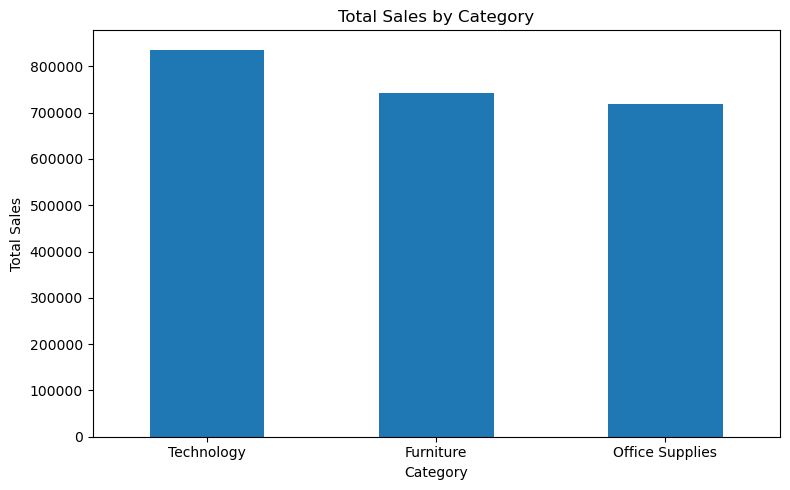

In [40]:
category_sales.plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

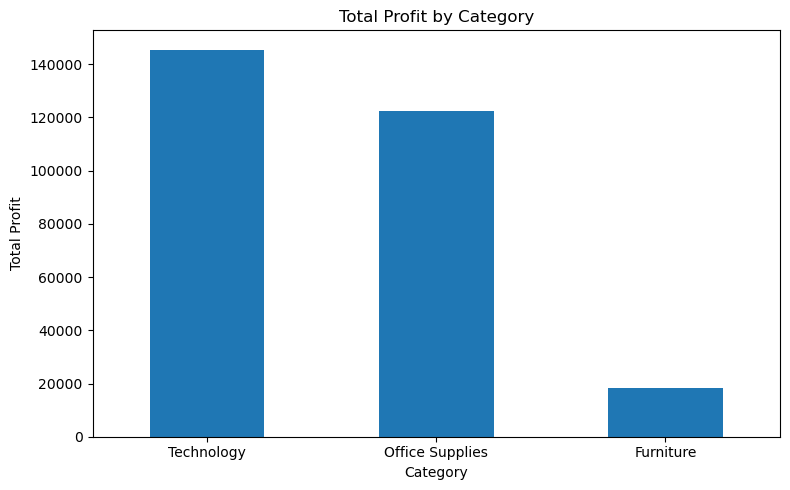

In [41]:
category_profit.plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Profit by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [42]:
category_loss = df_clean[df_clean["Profit"] < 0].groupby("Category").size()

category_loss

Category
Furniture          714
Office Supplies    886
Technology         271
dtype: int64

In [43]:
subcategory_summary = df_clean.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Total_Quantity=("Quantity", "sum")
).sort_values("Total_Sales", ascending=False)

subcategory_summary

,Total_Sales,Total_Profit,Total_Quantity
Sub-Category,,,
Phones,330007.0540,44515.7306,3289
Chairs,328449.1030,26590.1663,2356
Storage,223843.6080,21278.8264,3158
Tables,206965.5320,-17725.4811,1241
Binders,203412.7330,30221.7633,5974
Machines,189238.6310,3384.7569,440
Accessories,167380.3180,41936.6357,2976
Copiers,149528.0300,55617.8249,234
Bookcases,114879.9963,-3472.5560,868


In [44]:
subcategory_summary["Profit_Margin_%"] = (
    subcategory_summary["Total_Profit"]
    / subcategory_summary["Total_Sales"]
    * 100
)

subcategory_summary

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289,13.489327
Chairs,328449.1030,26590.1663,2356,8.095673
Storage,223843.6080,21278.8264,3158,9.506113
Tables,206965.5320,-17725.4811,1241,-8.564460
Binders,203412.7330,30221.7633,5974,14.857361
Machines,189238.6310,3384.7569,440,1.788618
Accessories,167380.3180,41936.6357,2976,25.054700
Copiers,149528.0300,55617.8249,234,37.195585
Bookcases,114879.9963,-3472.5560,868,-3.022768


In [45]:
subcategory_summary.sort_values(
    "Total_Sales",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289,13.489327
Chairs,328449.1030,26590.1663,2356,8.095673
Storage,223843.6080,21278.8264,3158,9.506113
Tables,206965.5320,-17725.4811,1241,-8.564460
Binders,203412.7330,30221.7633,5974,14.857361
Machines,189238.6310,3384.7569,440,1.788618
Accessories,167380.3180,41936.6357,2976,25.054700
Copiers,149528.0300,55617.8249,234,37.195585
Bookcases,114879.9963,-3472.5560,868,-3.022768


In [46]:
subcategory_summary.sort_values(
    "Total_Profit",
    ascending=False
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Copiers,149528.030,55617.8249,234,37.195585
Phones,330007.054,44515.7306,3289,13.489327
Accessories,167380.318,41936.6357,2976,25.054700
Paper,78479.206,34053.5693,5178,43.391837
Binders,203412.733,30221.7633,5974,14.857361
Chairs,328449.103,26590.1663,2356,8.095673
Storage,223843.608,21278.8264,3158,9.506113
Appliances,107532.161,18138.0054,1729,16.867517
Furnishings,91705.164,13059.1436,3563,14.240358


In [47]:
subcategory_summary.sort_values(
    "Total_Profit",
    ascending=True
).head(10)

,Total_Sales,Total_Profit,Total_Quantity,Profit_Margin_%
Sub-Category,,,,
Tables,206965.5320,-17725.4811,1241,-8.564460
Bookcases,114879.9963,-3472.5560,868,-3.022768
Supplies,46673.5380,-1189.0995,647,-2.547695
Fasteners,3024.2800,949.5182,914,31.396504
Machines,189238.6310,3384.7569,440,1.788618
Labels,12486.3120,5546.2540,1400,44.418672
Art,27118.7920,6527.7870,3000,24.071083
Envelopes,16476.4020,6964.1767,906,42.267582
Furnishings,91705.1640,13059.1436,3563,14.240358


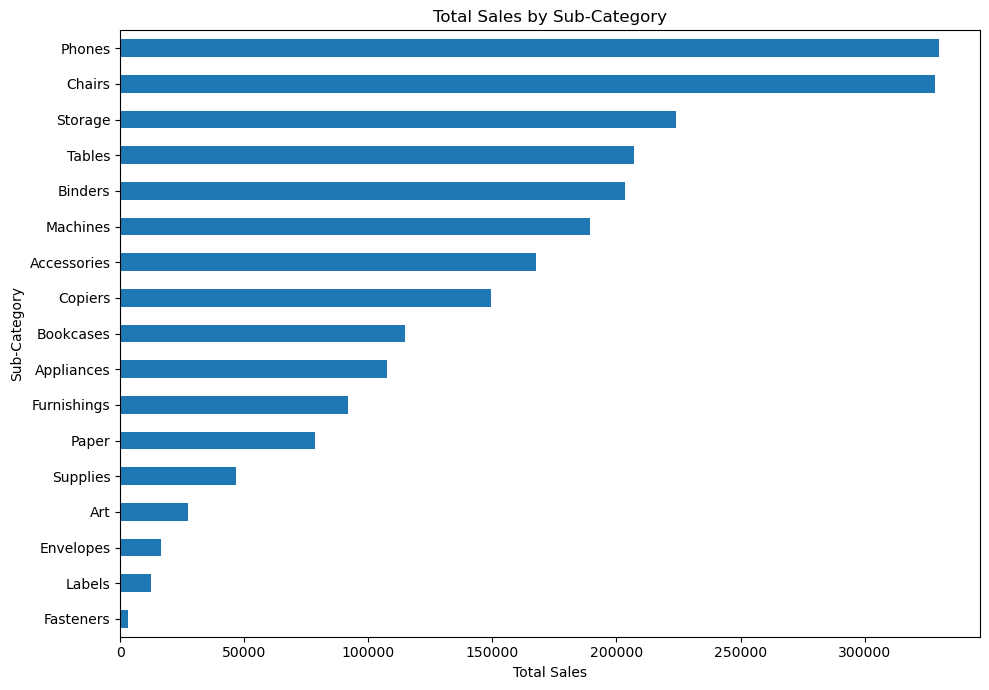

In [48]:
subcategory_sales = (
    df_clean.groupby("Sub-Category")["Sales"]
    .sum()
    .sort_values(ascending=True)
)

subcategory_sales.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Sales by Sub-Category"
)

plt.xlabel("Total Sales")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

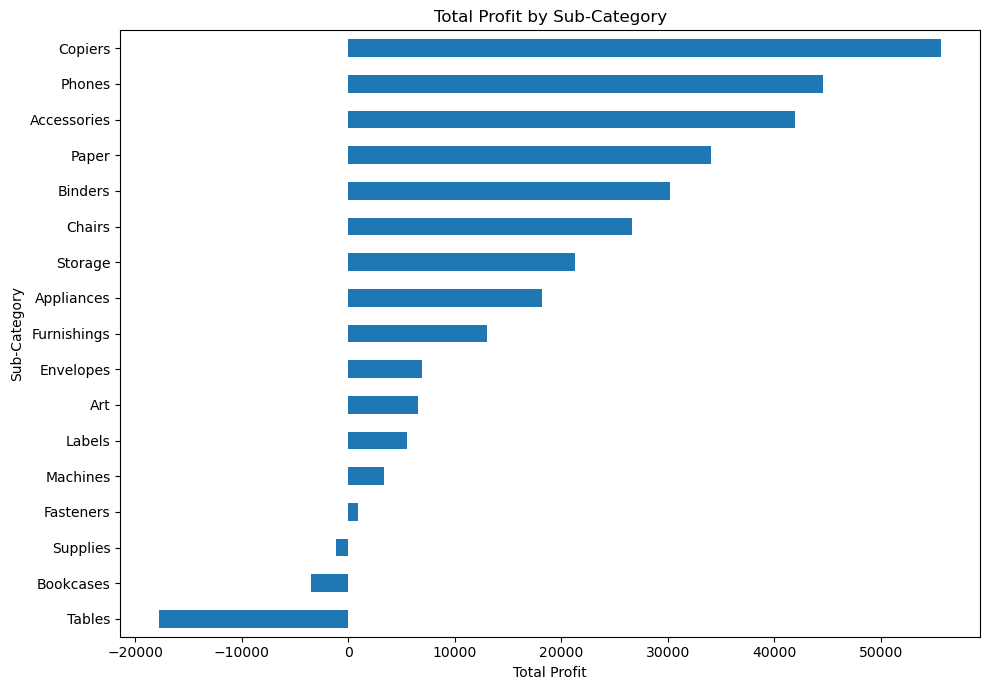

In [49]:
subcategory_profit = (
    df_clean.groupby("Sub-Category")["Profit"]
    .sum()
    .sort_values(ascending=True)
)

subcategory_profit.plot(
    kind="barh",
    figsize=(10, 7),
    title="Total Profit by Sub-Category"
)

plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.tight_layout()
plt.show()

In [50]:
discount_profit = df_clean.groupby("Discount").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum"),
    Average_Profit=("Profit", "mean"),
    Number_of_Records=("Profit", "size")
)

discount_profit

,Total_Sales,Total_Profit,Average_Profit,Number_of_Records
Discount,,,,
0.00,1.087908e+06,320987.6032,66.900292,4798
0.10,5.436935e+04,9029.1770,96.055074,94
0.15,2.755852e+04,1418.9915,27.288298,52
0.20,7.645944e+05,90337.3060,24.702572,3657
0.30,1.032267e+05,-10369.2774,-45.679636,227
0.32,1.449346e+04,-2391.1377,-88.560656,27
0.40,1.164178e+05,-23057.0504,-111.927429,206
0.45,5.484974e+03,-2493.1111,-226.646464,11
0.50,5.891854e+04,-20506.4281,-310.703456,66


In [51]:
discount_profit["Profit_Margin_%"] = (
    discount_profit["Total_Profit"]
    / discount_profit["Total_Sales"]
    * 100
)

discount_profit

,Total_Sales,Total_Profit,Average_Profit,Number_of_Records,Profit_Margin_%
Discount,,,,,
0.00,1.087908e+06,320987.6032,66.900292,4798,29.505019
0.10,5.436935e+04,9029.1770,96.055074,94,16.607108
0.15,2.755852e+04,1418.9915,27.288298,52,5.149012
0.20,7.645944e+05,90337.3060,24.702572,3657,11.815063
0.30,1.032267e+05,-10369.2774,-45.679636,227,-10.045155
0.32,1.449346e+04,-2391.1377,-88.560656,27,-16.498047
0.40,1.164178e+05,-23057.0504,-111.927429,206,-19.805437
0.45,5.484974e+03,-2493.1111,-226.646464,11,-45.453472
0.50,5.891854e+04,-20506.4281,-310.703456,66,-34.804712


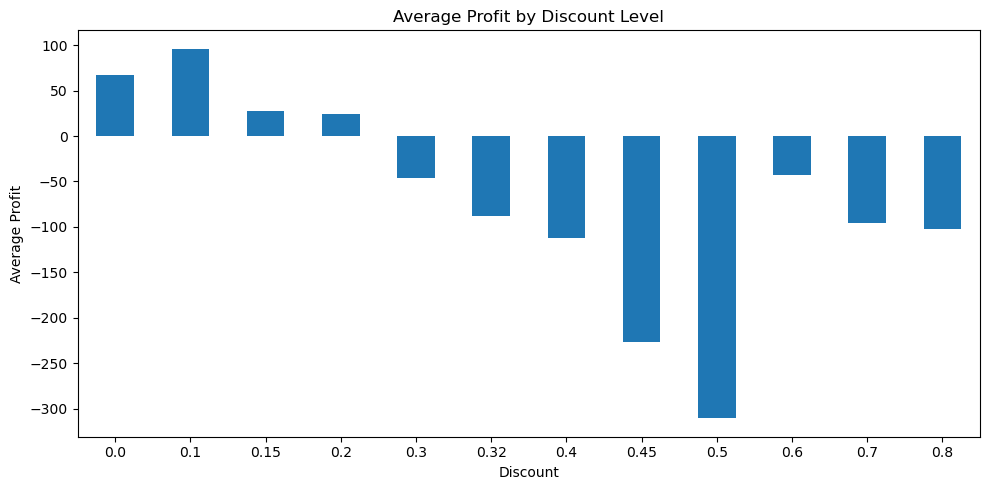

In [52]:
discount_avg_profit = df_clean.groupby("Discount")["Profit"].mean()

discount_avg_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Average Profit by Discount Level"
)

plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

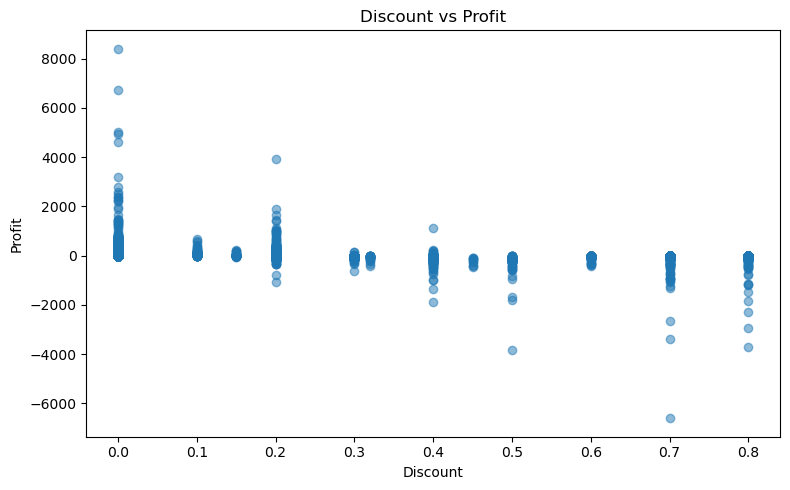

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df_clean["Discount"],
    df_clean["Profit"],
    alpha=0.5
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.show()

In [54]:
df_clean[["Discount", "Profit"]].corr()

,Discount,Profit
Discount,1.000000,-0.219487
Profit,-0.219487,1.000000


In [55]:
high_discount = df_clean[df_clean["Discount"] >= 0.50]

high_discount.shape

(922, 21)

In [56]:
high_discount["Profit"].describe()

count     922.000000
mean     -105.277093
std       383.309932
min     -6599.978000
25%       -49.339500
50%       -13.352700
75%        -4.853475
max        -0.596400
Name: Profit, dtype: float64

In [57]:
discount_loss = df_clean[df_clean["Profit"] < 0].groupby("Discount").size()

discount_loss

Discount
0.10      4
0.15     17
0.20    502
0.30    208
0.32     27
0.40    180
0.45     11
0.50     66
0.60    138
0.70    418
0.80    300
dtype: int64

In [75]:
monthly_sales = (
    df_clean
    .groupby(df_clean["Order Date"].dt.to_period("M"))["Sales"]
    .sum()
)

monthly_sales.head(10)

Order Date
2014-01    14236.8950
2014-02     4519.8920
2014-03    55691.0090
2014-04    28295.3450
2014-05    23648.2870
2014-06    34595.1276
2014-07    33946.3930
2014-08    27909.4685
2014-09    81777.3508
2014-10    31453.3930
Freq: M, Name: Sales, dtype: float64

In [71]:
monthly_profit = (
    df_clean
    .groupby(df_clean["Order Date"].dt.to_period("M"))["Profit"]
    .sum()
)

monthly_profit.head(10)

Order Date
2014-01    2450.1907
2014-02     862.3084
2014-03     498.7299
2014-04    3488.8352
2014-05    2738.7096
2014-06    4976.5244
2014-07    -841.4826
2014-08    5318.1050
2014-09    8328.0994
2014-10    3448.2573
Freq: M, Name: Profit, dtype: float64

In [72]:
monthly_summary = pd.DataFrame({
    "Total_Sales": monthly_sales,
    "Total_Profit": monthly_profit
})

monthly_summary.head(10)

,Total_Sales,Total_Profit
Order Date,,
2014-01,14236.8950,2450.1907
2014-02,4519.8920,862.3084
2014-03,55691.0090,498.7299
2014-04,28295.3450,3488.8352
2014-05,23648.2870,2738.7096
2014-06,34595.1276,4976.5244
2014-07,33946.3930,-841.4826
2014-08,27909.4685,5318.1050
2014-09,81777.3508,8328.0994


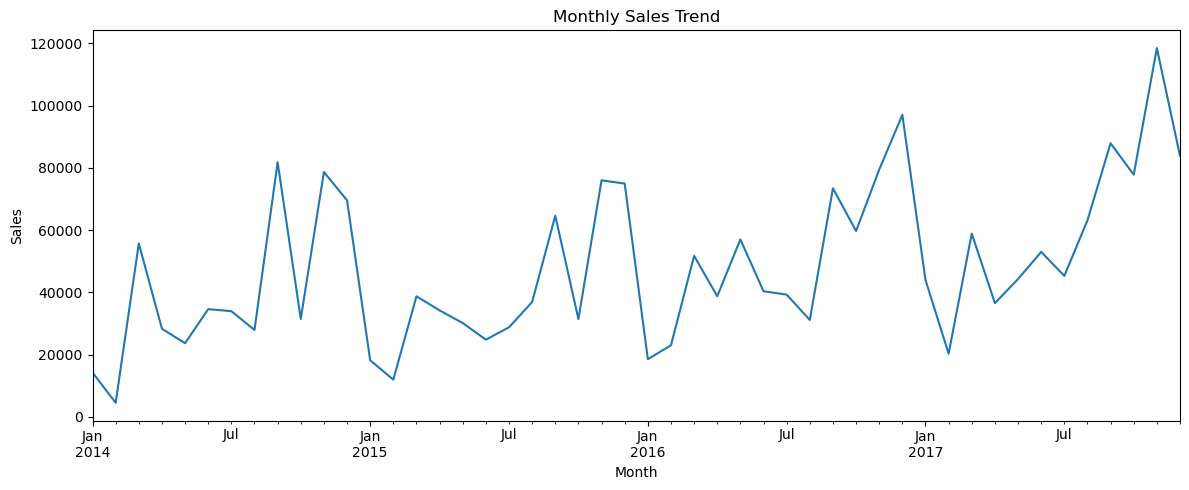

In [73]:
monthly_summary["Total_Sales"].plot(
    figsize=(12, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

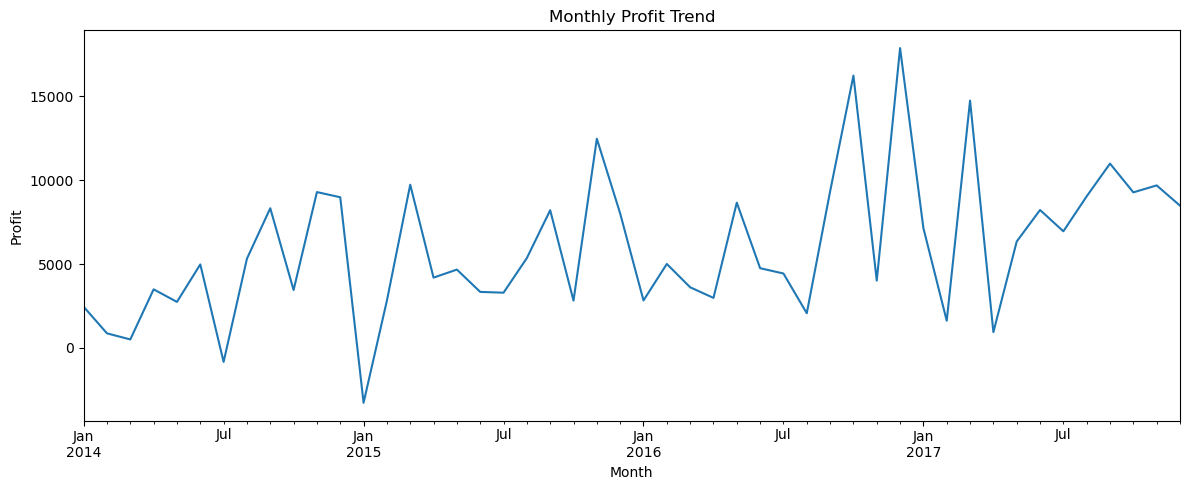

In [74]:
monthly_summary["Total_Profit"].plot(
    figsize=(12, 5),
    title="Monthly Profit Trend"
)

plt.xlabel("Month")
plt.ylabel("Profit")
plt.tight_layout()
plt.show()

In [76]:
yearly_summary = (
    df_clean
    .groupby(df_clean["Order Date"].dt.year)
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
)

yearly_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Order Date,,,,
2014,484247.4981,49543.9741,7581,969
2015,470532.5090,61618.6037,7979,1038
2016,609205.5980,81795.1743,9837,1315
2017,733215.2552,93439.2696,12476,1687


In [77]:
yearly_summary["Profit_Margin_%"] = (
    yearly_summary["Total_Profit"]
    / yearly_summary["Total_Sales"]
    * 100
)

yearly_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Order Date,,,,,
2014,484247.4981,49543.9741,7581,969,10.231126
2015,470532.5090,61618.6037,7979,1038,13.095504
2016,609205.5980,81795.1743,9837,1315,13.426530
2017,733215.2552,93439.2696,12476,1687,12.743771


In [78]:
yearly_summary["Sales_Growth_%"] = (
    yearly_summary["Total_Sales"].pct_change()
    * 100
)

yearly_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%,Sales_Growth_%
Order Date,,,,,,
2014,484247.4981,49543.9741,7581,969,10.231126,NaN
2015,470532.5090,61618.6037,7979,1038,13.095504,-2.832227
2016,609205.5980,81795.1743,9837,1315,13.426530,29.471521
2017,733215.2552,93439.2696,12476,1687,12.743771,20.355962


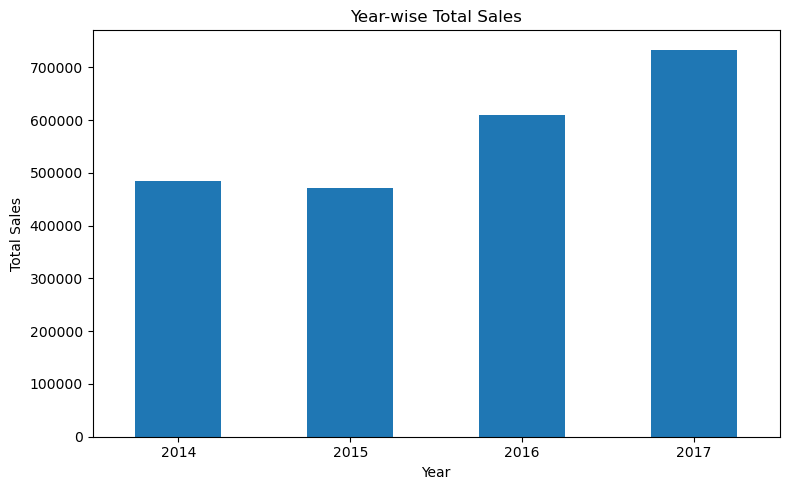

In [79]:
yearly_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Year-wise Total Sales"
)

plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

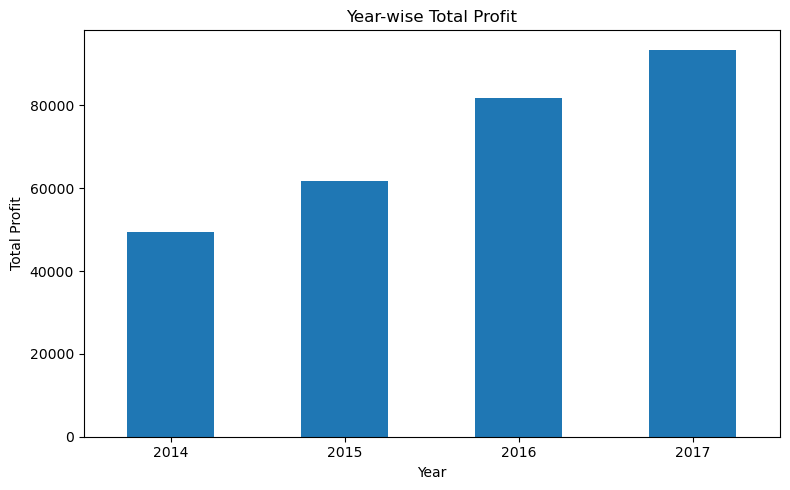

In [80]:
yearly_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Year-wise Total Profit"
)

plt.xlabel("Year")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [81]:
yearly_summary["Average_Order_Value"] = (
    yearly_summary["Total_Sales"]
    / yearly_summary["Number_of_Orders"]
)

yearly_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%,Sales_Growth_%,Average_Order_Value
Order Date,,,,,,,
2014,484247.4981,49543.9741,7581,969,10.231126,NaN,499.739420
2015,470532.5090,61618.6037,7979,1038,13.095504,-2.832227,453.306849
2016,609205.5980,81795.1743,9837,1315,13.426530,29.471521,463.274219
2017,733215.2552,93439.2696,12476,1687,12.743771,20.355962,434.626707


In [82]:
region_summary = (
    df_clean
    .groupby("Region")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

region_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Region,,,,
West,725457.8245,108418.4489,12266,1611
East,678781.2400,91522.7800,10618,1401
Central,501239.8908,39706.3625,8780,1175
South,391721.9050,46749.4303,6209,822


In [83]:
region_summary["Profit_Margin_%"] = (
    region_summary["Total_Profit"]
    / region_summary["Total_Sales"]
    * 100
)

region_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Region,,,,,
West,725457.8245,108418.4489,12266,1611,14.944831
East,678781.2400,91522.7800,10618,1401,13.483399
Central,501239.8908,39706.3625,8780,1175,7.921629
South,391721.9050,46749.4303,6209,822,11.934342


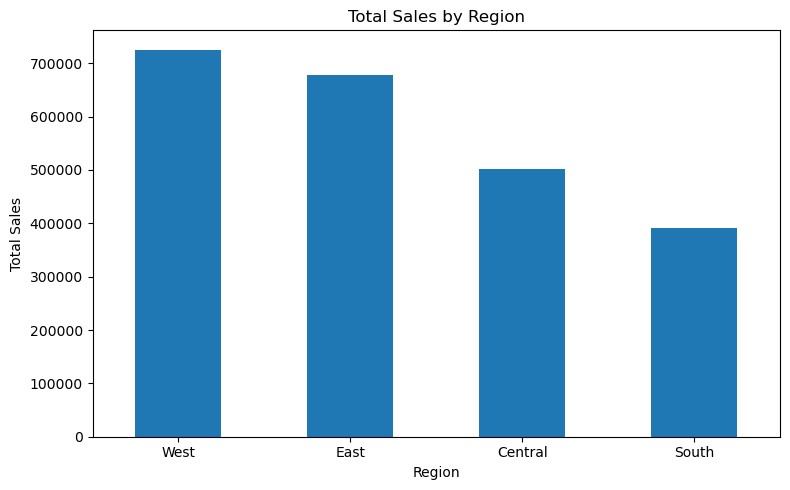

In [84]:
region_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Region"
)

plt.xlabel("Region")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

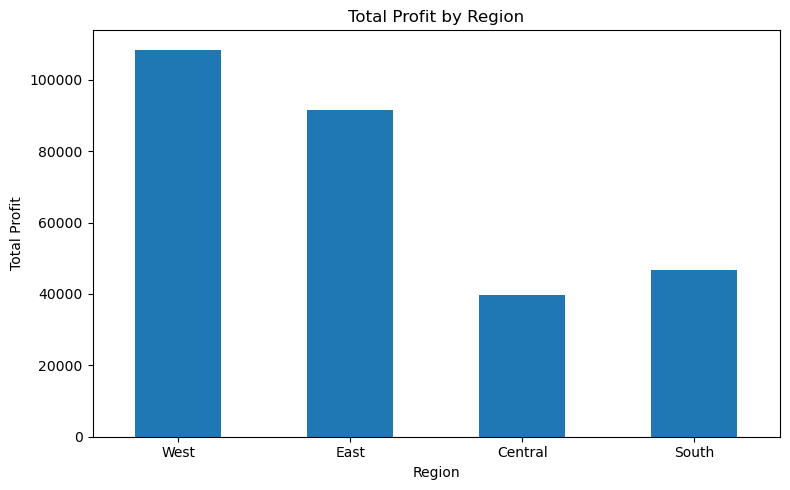

In [85]:
region_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Profit by Region"
)

plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [86]:
region_loss = (
    df_clean[df_clean["Profit"] < 0]
    .groupby("Region")
    .size()
    .sort_values(ascending=False)
)

region_loss

Region
Central    741
East       553
West       318
South      259
dtype: int64

In [87]:
state_summary = (
    df_clean
    .groupby("State")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

state_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
State,,,,
California,457687.6315,76381.3871,7667,1021
New York,310876.2710,74038.5486,4224,562
Texas,170188.0458,-25729.3563,3724,487
Washington,138641.2700,33402.6517,1883,256
Pennsylvania,116511.9140,-15559.9603,2153,288
Florida,89473.7080,-3399.3017,1379,200
Illinois,80166.1010,-12607.8870,1845,276
Ohio,78258.1360,-16971.3766,1759,236
Michigan,76269.6140,24463.1876,946,117


In [88]:
state_summary["Profit_Margin_%"] = (
    state_summary["Total_Profit"]
    / state_summary["Total_Sales"]
    * 100
)

state_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
State,,,,,
California,457687.6315,76381.3871,7667,1021,16.688541
New York,310876.2710,74038.5486,4224,562,23.816082
Texas,170188.0458,-25729.3563,3724,487,-15.118192
Washington,138641.2700,33402.6517,1883,256,24.092863
Pennsylvania,116511.9140,-15559.9603,2153,288,-13.354823
Florida,89473.7080,-3399.3017,1379,200,-3.799219
Illinois,80166.1010,-12607.8870,1845,276,-15.727205
Ohio,78258.1360,-16971.3766,1759,236,-21.686405
Michigan,76269.6140,24463.1876,946,117,32.074618


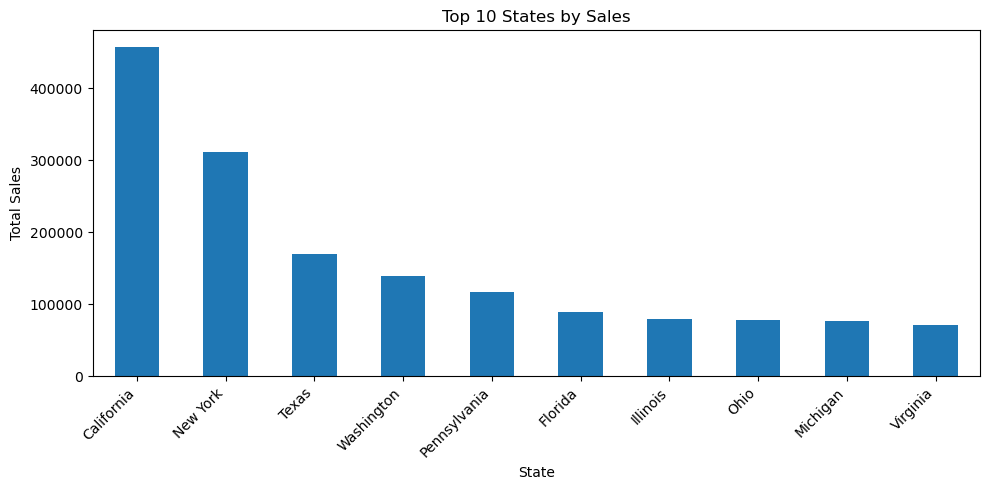

In [89]:
top10_state_sales = state_summary["Total_Sales"].head(10)

top10_state_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 States by Sales"
)

plt.xlabel("State")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

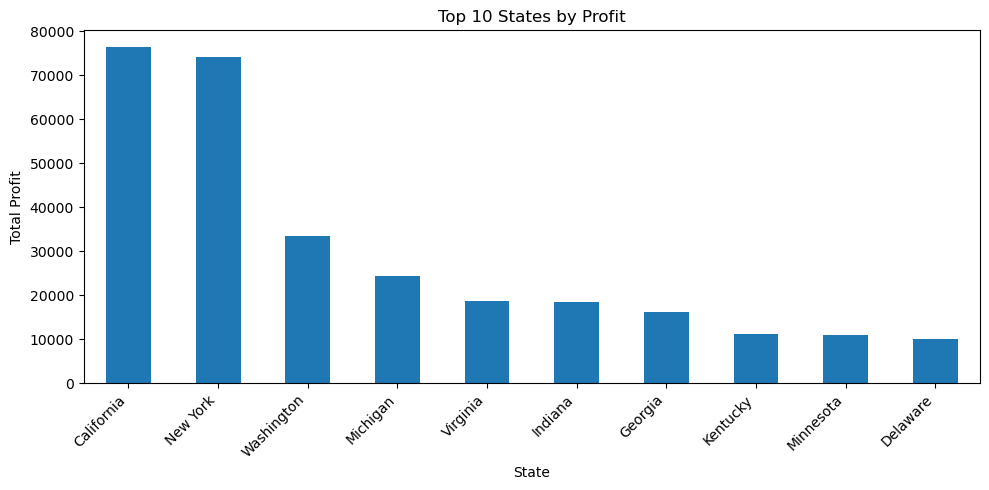

In [90]:
top10_state_profit = (
    state_summary
    .sort_values("Total_Profit", ascending=False)
    ["Total_Profit"]
    .head(10)
)

top10_state_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 States by Profit"
)

plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

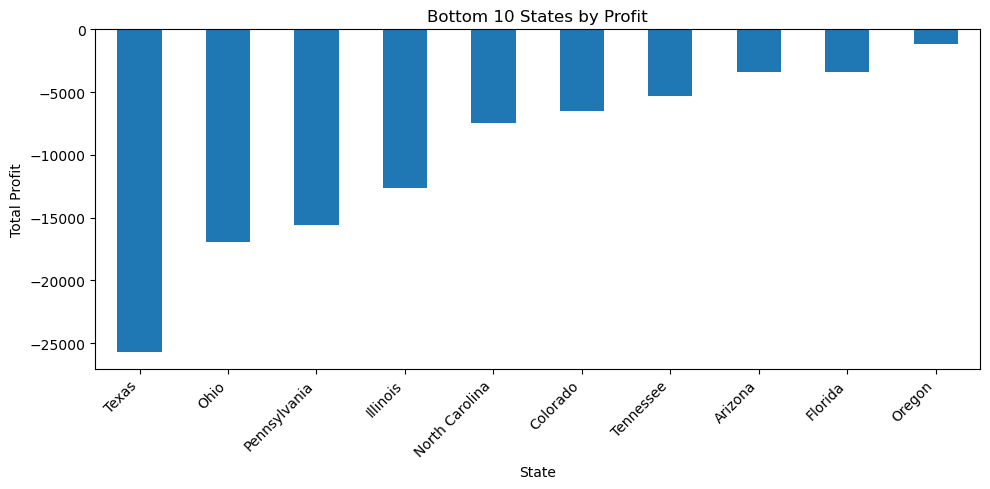

In [91]:
bottom10_state_profit = (
    state_summary
    .sort_values("Total_Profit", ascending=True)
    ["Total_Profit"]
    .head(10)
)

bottom10_state_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Bottom 10 States by Profit"
)

plt.xlabel("State")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [92]:
state_loss = (
    df_clean[df_clean["Profit"] < 0]
    .groupby("State")
    .size()
    .sort_values(ascending=False)
)

state_loss.head(10)

State
Texas             486
Pennsylvania      278
Illinois          255
Ohio              209
Florida           126
California        105
Arizona            85
North Carolina     68
Colorado           66
Tennessee          65
dtype: int64

In [93]:
city_summary = (
    df_clean
    .groupby("City")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

city_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
City,,,,
New York City,256368.1610,62036.9837,3417,450
Los Angeles,175851.3410,30440.7579,2879,384
Seattle,119540.7420,29156.0967,1590,212
San Francisco,112669.0920,17507.3854,1935,265
Philadelphia,109077.0130,-13837.7674,1981,265
Houston,64504.7604,-10153.5485,1466,188
Chicago,48539.5410,-6654.5688,1132,171
San Diego,47521.0290,6377.1960,670,88
Jacksonville,44713.1830,-2323.8350,429,61


In [94]:
city_summary["Profit_Margin_%"] = (
    city_summary["Total_Profit"]
    / city_summary["Total_Sales"]
    * 100
)

city_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
City,,,,,
New York City,256368.1610,62036.9837,3417,450,24.198396
Los Angeles,175851.3410,30440.7579,2879,384,17.310507
Seattle,119540.7420,29156.0967,1590,212,24.390092
San Francisco,112669.0920,17507.3854,1935,265,15.538765
Philadelphia,109077.0130,-13837.7674,1981,265,-12.686236
Houston,64504.7604,-10153.5485,1466,188,-15.740774
Chicago,48539.5410,-6654.5688,1132,171,-13.709583
San Diego,47521.0290,6377.1960,670,88,13.419735
Jacksonville,44713.1830,-2323.8350,429,61,-5.197203


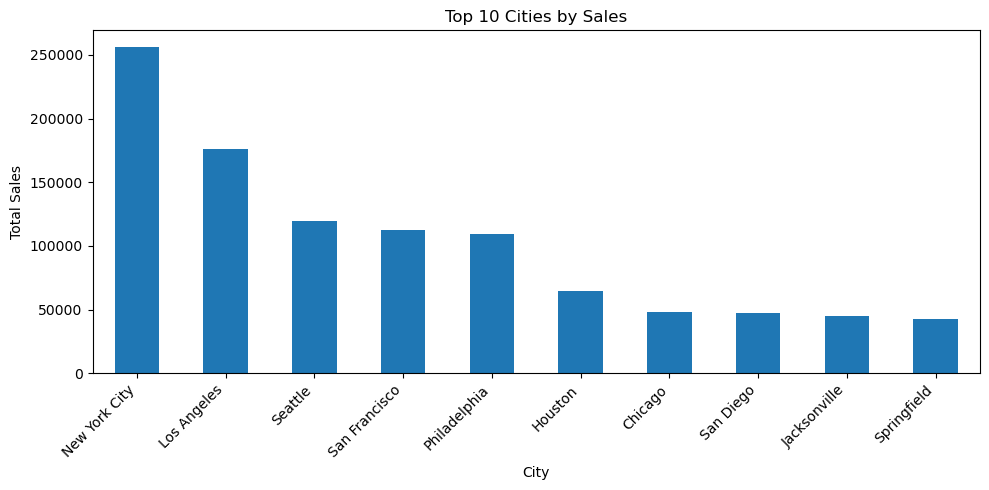

In [95]:
top10_city_sales = city_summary["Total_Sales"].head(10)

top10_city_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Cities by Sales"
)

plt.xlabel("City")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

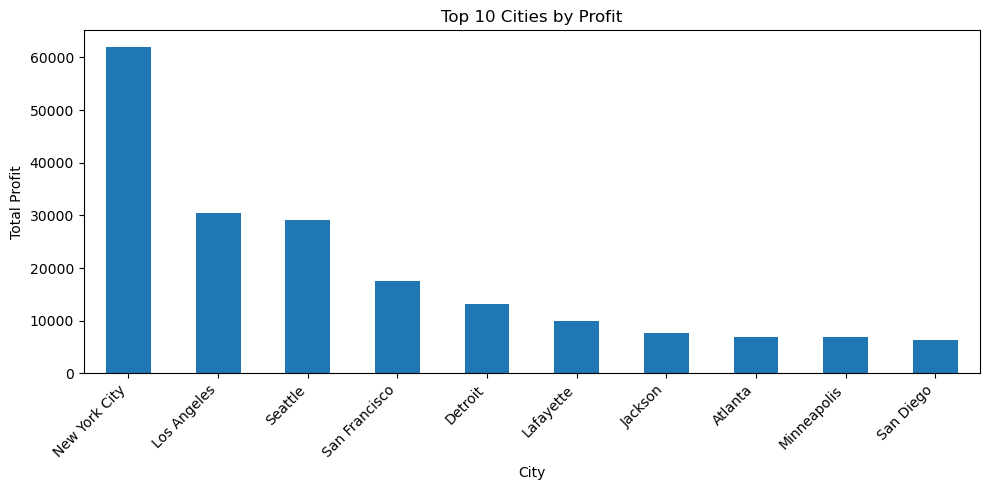

In [96]:
top10_city_profit = (
    city_summary
    .sort_values("Total_Profit", ascending=False)
    ["Total_Profit"]
    .head(10)
)

top10_city_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Cities by Profit"
)

plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

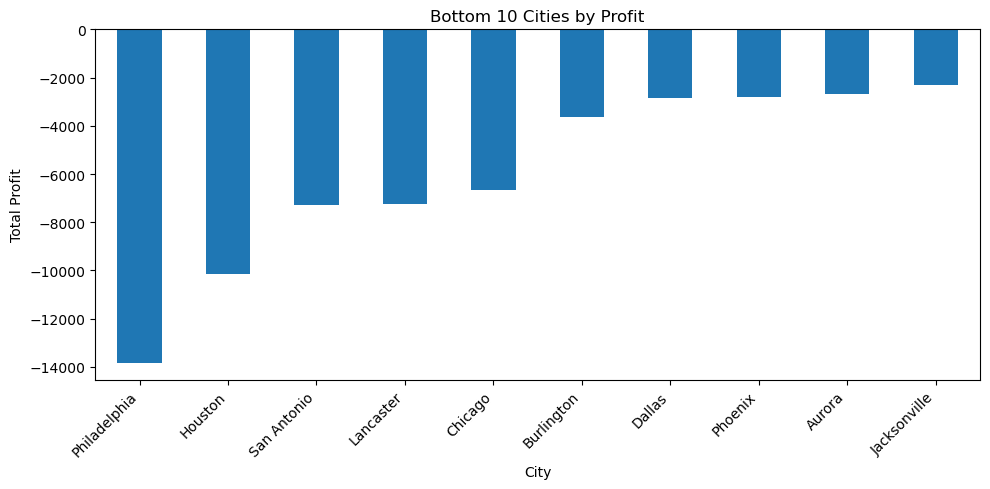

In [97]:
bottom10_city_profit = (
    city_summary
    .sort_values("Total_Profit", ascending=True)
    ["Total_Profit"]
    .head(10)
)

bottom10_city_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Bottom 10 Cities by Profit"
)

plt.xlabel("City")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [98]:
city_loss = (
    df_clean[df_clean["Profit"] < 0]
    .groupby("City")
    .size()
    .sort_values(ascending=False)
)

city_loss.head(10)

City
Philadelphia     250
Houston          185
Chicago          155
Dallas            73
Columbus          51
New York City     40
Jacksonville      40
Los Angeles       37
Aurora            35
San Antonio       33
dtype: int64

In [99]:
segment_summary = (
    df_clean
    .groupby("Segment")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

segment_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Segment,,,,
Consumer,1.161401e+06,134119.2092,19521,2586
Corporate,7.061464e+05,91979.1340,11608,1514
Home Office,4.296531e+05,60298.6785,6744,909


In [100]:
segment_summary["Profit_Margin_%"] = (
    segment_summary["Total_Profit"]
    / segment_summary["Total_Sales"]
    * 100
)

segment_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Segment,,,,,
Consumer,1.161401e+06,134119.2092,19521,2586,11.548050
Corporate,7.061464e+05,91979.1340,11608,1514,13.025506
Home Office,4.296531e+05,60298.6785,6744,909,14.034269


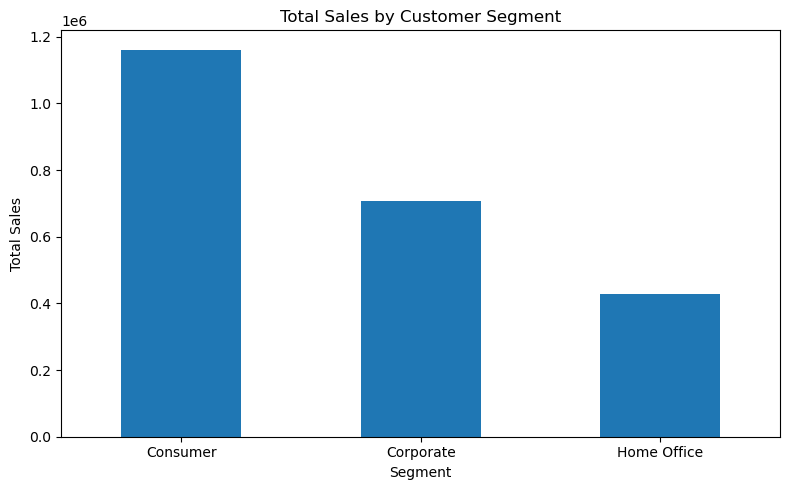

In [101]:
segment_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Customer Segment"
)

plt.xlabel("Segment")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

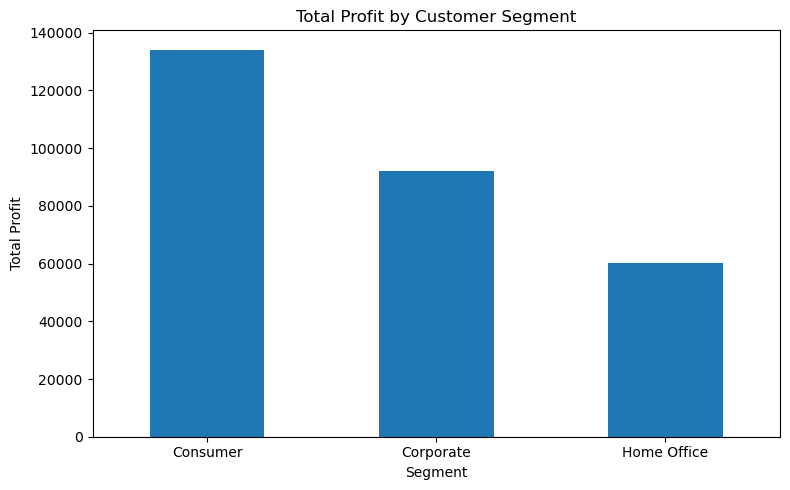

In [102]:
segment_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Profit by Customer Segment"
)

plt.xlabel("Segment")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

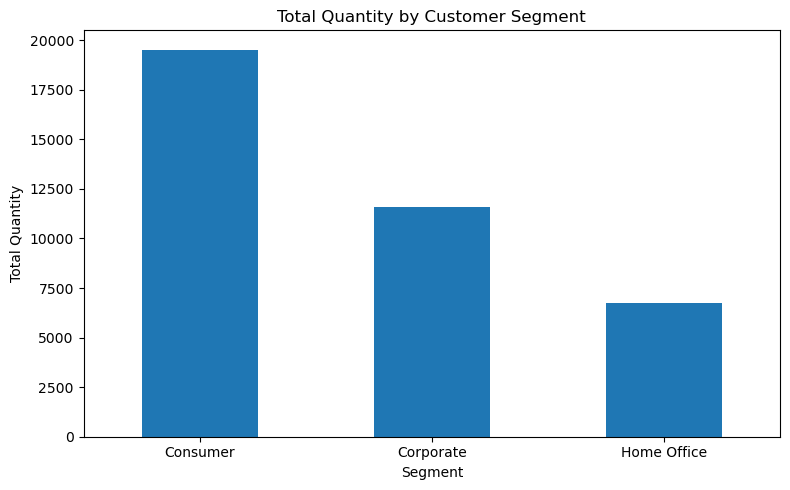

In [103]:
segment_summary["Total_Quantity"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Quantity by Customer Segment"
)

plt.xlabel("Segment")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [104]:
category_summary = (
    df_clean
    .groupby("Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

category_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Category,,,,
Technology,836154.0330,145454.9481,6939,1544
Furniture,741999.7953,18451.2728,8028,1764
Office Supplies,719047.0320,122490.8008,22906,3742


In [105]:
category_summary["Profit_Margin_%"] = (
    category_summary["Total_Profit"]
    / category_summary["Total_Sales"]
    * 100
)

category_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Category,,,,,
Technology,836154.0330,145454.9481,6939,1544,17.395712
Furniture,741999.7953,18451.2728,8028,1764,2.486695
Office Supplies,719047.0320,122490.8008,22906,3742,17.035158


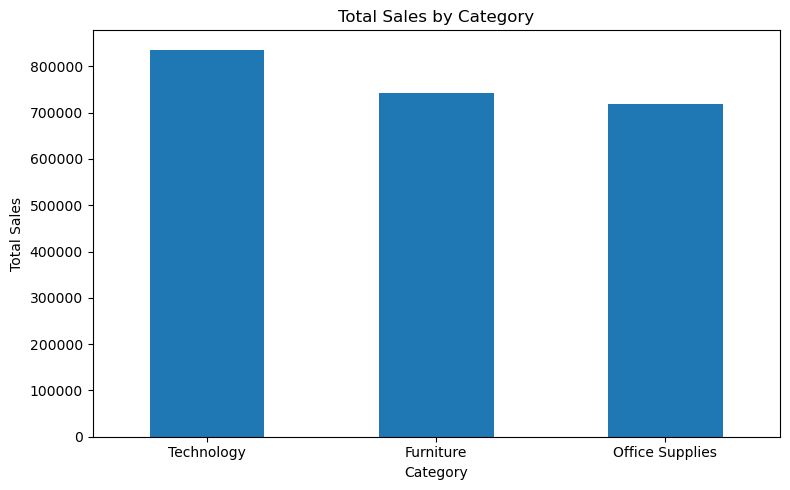

In [106]:
category_summary["Total_Sales"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Sales by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

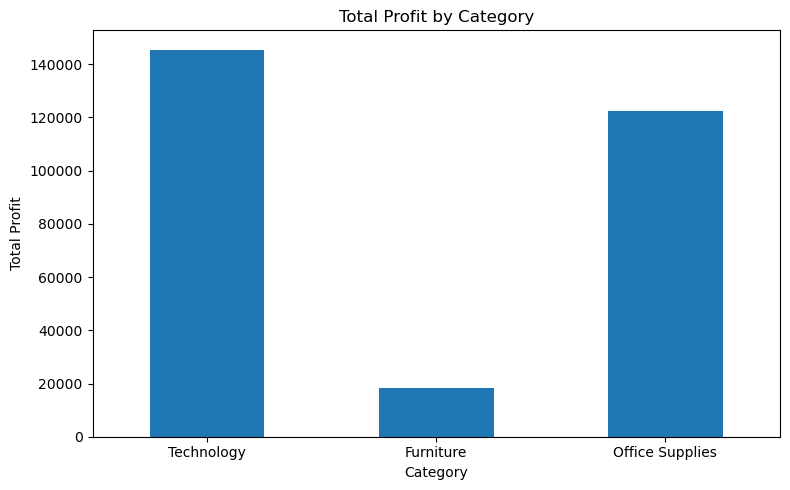

In [107]:
category_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Profit by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

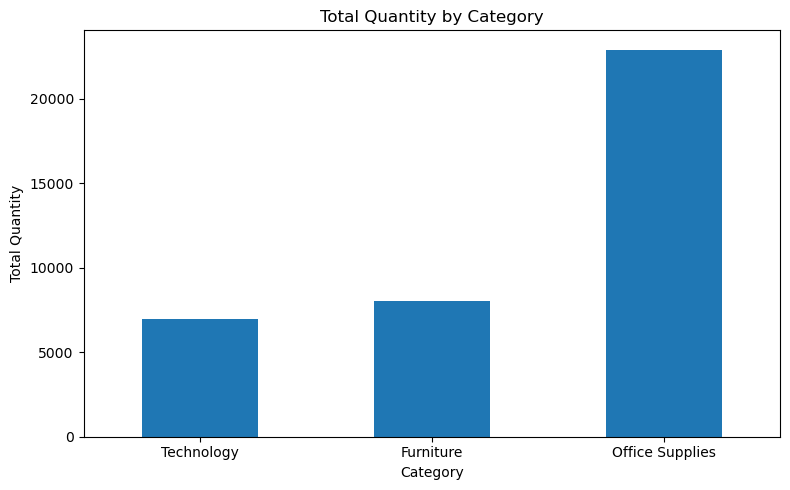

In [108]:
category_summary["Total_Quantity"].plot(
    kind="bar",
    figsize=(8, 5),
    title="Total Quantity by Category"
)

plt.xlabel("Category")
plt.ylabel("Total Quantity")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [109]:
subcategory_summary = (
    df_clean
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

subcategory_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Sub-Category,,,,
Phones,330007.0540,44515.7306,3289,814
Chairs,328449.1030,26590.1663,2356,576
Storage,223843.6080,21278.8264,3158,777
Tables,206965.5320,-17725.4811,1241,307
Binders,203412.7330,30221.7633,5974,1316
Machines,189238.6310,3384.7569,440,112
Accessories,167380.3180,41936.6357,2976,718
Copiers,149528.0300,55617.8249,234,68
Bookcases,114879.9963,-3472.5560,868,224


In [110]:
subcategory_summary["Profit_Margin_%"] = (
    subcategory_summary["Total_Profit"]
    / subcategory_summary["Total_Sales"]
    * 100
)

subcategory_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Sub-Category,,,,,
Phones,330007.0540,44515.7306,3289,814,13.489327
Chairs,328449.1030,26590.1663,2356,576,8.095673
Storage,223843.6080,21278.8264,3158,777,9.506113
Tables,206965.5320,-17725.4811,1241,307,-8.564460
Binders,203412.7330,30221.7633,5974,1316,14.857361
Machines,189238.6310,3384.7569,440,112,1.788618
Accessories,167380.3180,41936.6357,2976,718,25.054700
Copiers,149528.0300,55617.8249,234,68,37.195585
Bookcases,114879.9963,-3472.5560,868,224,-3.022768


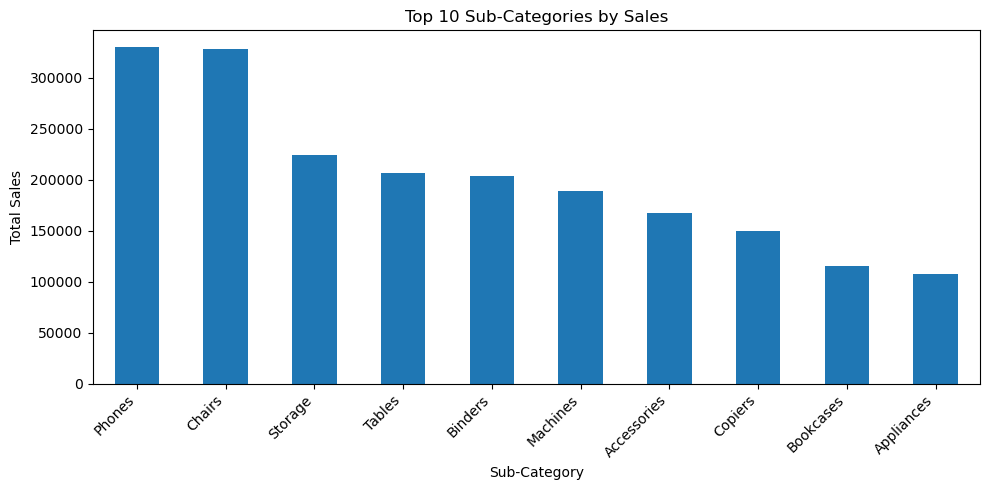

In [111]:
top10_subcategory_sales = (
    subcategory_summary["Total_Sales"]
    .head(10)
)

top10_subcategory_sales.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Sub-Categories by Sales"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

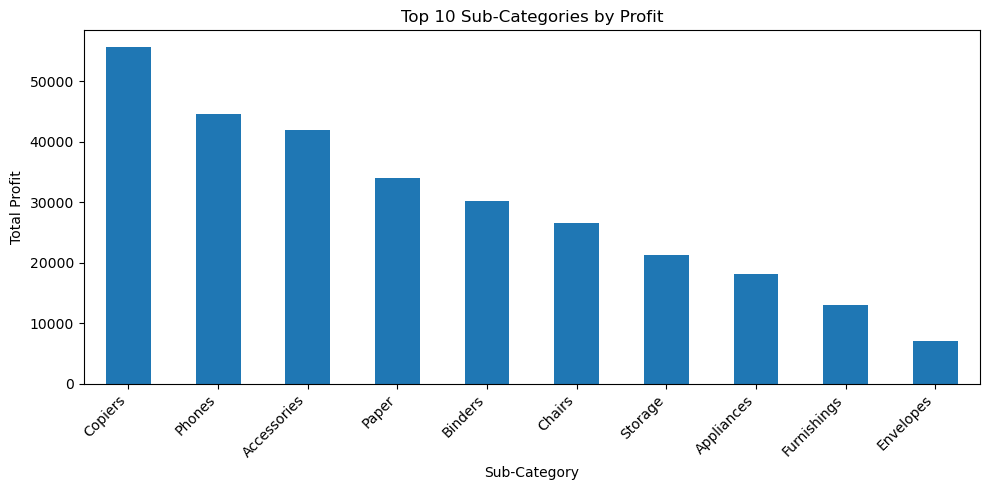

In [112]:
top10_subcategory_profit = (
    subcategory_summary
    .sort_values("Total_Profit", ascending=False)
    ["Total_Profit"]
    .head(10)
)

top10_subcategory_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Top 10 Sub-Categories by Profit"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

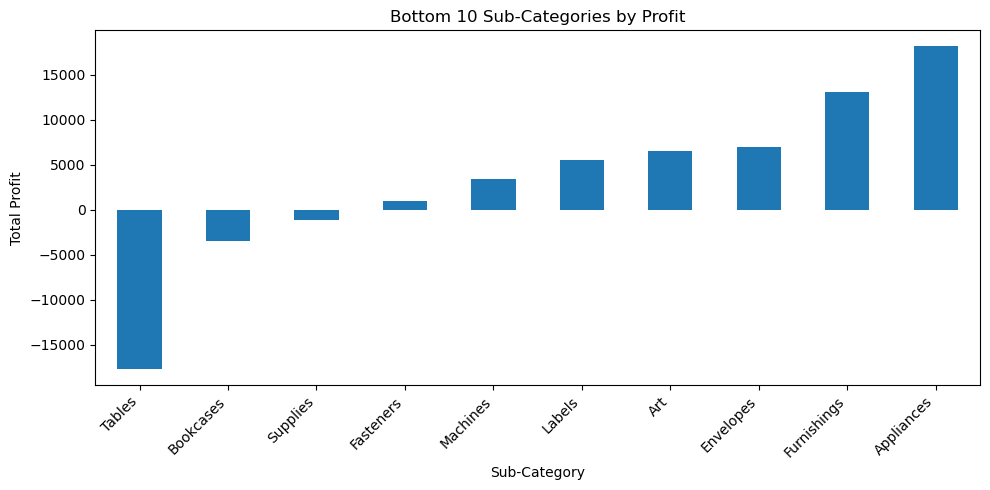

In [114]:
bottom10_subcategory_profit = (
    subcategory_summary
    .sort_values("Total_Profit", ascending=True)
    ["Total_Profit"]
    .head(10)
)

bottom10_subcategory_profit.plot(
    kind="bar",
    figsize=(10, 5),
    title="Bottom 10 Sub-Categories by Profit"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [115]:
discount_subcategory = (
    df_clean
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .reset_index()
)

discount_subcategory.head(20)

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
0,Accessories,0.00,118370.3100,35289.2539,1835,435
1,Accessories,0.20,49010.0080,6647.3818,1141,283
2,Appliances,0.00,78066.1900,23183.7361,1021,265
3,Appliances,0.10,4324.1490,1086.0808,55,16
4,Appliances,0.20,21759.2880,2497.8297,418,105
5,Appliances,0.80,3382.5340,-8629.6412,235,65
6,Art,0.00,18014.6400,5380.6006,1904,452
7,Art,0.20,9104.1520,1147.1864,1096,279
8,Binders,0.00,81829.4800,39314.4507,1291,295
9,Binders,0.20,85442.6400,29417.8090,2227,495


In [116]:
discount_subcategory["Profit_Margin_%"] = (
    discount_subcategory["Total_Profit"]
    / discount_subcategory["Total_Sales"]
    * 100
)

discount_subcategory.head(20)

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
0,Accessories,0.00,118370.3100,35289.2539,1835,435,29.812589
1,Accessories,0.20,49010.0080,6647.3818,1141,283,13.563315
2,Appliances,0.00,78066.1900,23183.7361,1021,265,29.697538
3,Appliances,0.10,4324.1490,1086.0808,55,16,25.116637
4,Appliances,0.20,21759.2880,2497.8297,418,105,11.479372
5,Appliances,0.80,3382.5340,-8629.6412,235,65,-255.123561
6,Art,0.00,18014.6400,5380.6006,1904,452,29.867933
7,Art,0.20,9104.1520,1147.1864,1096,279,12.600695
8,Binders,0.00,81829.4800,39314.4507,1291,295,48.044361
9,Binders,0.20,85442.6400,29417.8090,2227,495,34.429892


In [117]:
loss_subcategory_discount = (
    discount_subcategory[
        discount_subcategory["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit")
)

loss_subcategory_discount

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
11,Binders,0.80,13581.2220,-21909.3980,953,203,-161.321257
41,Machines,0.70,15601.5090,-19579.3191,89,22,-125.496316
10,Binders,0.70,22559.3910,-16601.0984,1503,323,-73.588416
54,Tables,0.40,45614.4060,-16187.3968,292,72,-35.487466
5,Appliances,0.80,3382.5340,-8629.6412,235,65,-255.123561
56,Tables,0.50,13675.0100,-8615.3873,133,35,-63.000958
40,Machines,0.50,37935.0700,-7635.2291,32,11,-20.127099
22,Chairs,0.30,70005.5020,-6737.1167,614,149,-9.623696
46,Phones,0.40,34337.3520,-6385.7854,414,98,-18.597198
32,Furnishings,0.60,6644.7000,-5944.6552,501,127,-89.464614


In [118]:
tables_discount = (
    discount_subcategory[
        discount_subcategory["Sub-Category"] == "Tables"
    ]
    .sort_values("Discount")
)

tables_discount

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
51,Tables,0.00,71578.760,13276.2997,310,70,18.547820
52,Tables,0.20,45430.232,-303.5580,281,69,-0.668185
53,Tables,0.30,25182.150,-3402.3276,180,51,-13.510870
54,Tables,0.40,45614.406,-16187.3968,292,72,-35.487466
55,Tables,0.45,5484.974,-2493.1111,45,10,-45.453472
56,Tables,0.50,13675.010,-8615.3873,133,35,-63.000958


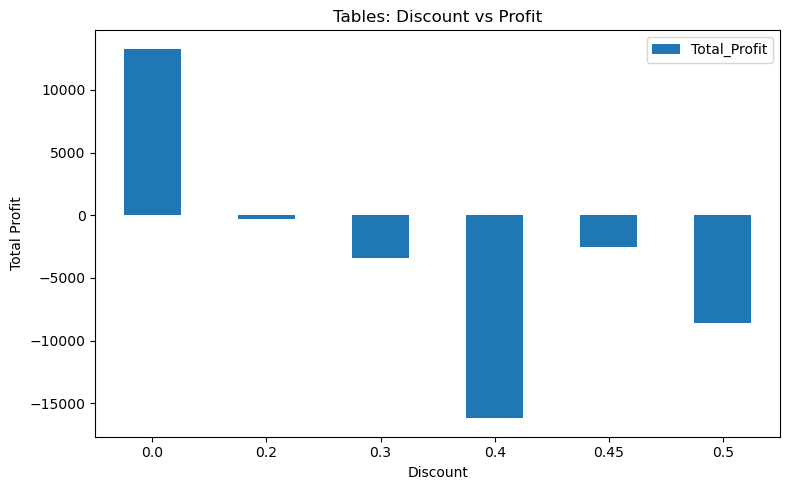

In [119]:
tables_discount.plot(
    x="Discount",
    y="Total_Profit",
    kind="bar",
    figsize=(8, 5),
    title="Tables: Discount vs Profit"
)

plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [120]:
discount_summary = (
    df_clean
    .groupby("Discount")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_index()
)

discount_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Discount,,,,
0.00,1.087908e+06,320987.6032,18267,2644
0.10,5.436935e+04,9029.1770,373,89
0.15,2.755852e+04,1418.9915,198,51
0.20,7.645944e+05,90337.3060,13660,2407
0.30,1.032267e+05,-10369.2774,849,211
0.32,1.449346e+04,-2391.1377,105,27
0.40,1.164178e+05,-23057.0504,786,185
0.45,5.484974e+03,-2493.1111,45,10
0.50,5.891854e+04,-20506.4281,241,64


In [121]:
discount_summary["Profit_Margin_%"] = (
    discount_summary["Total_Profit"]
    / discount_summary["Total_Sales"]
    * 100
)

discount_summary

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Discount,,,,,
0.00,1.087908e+06,320987.6032,18267,2644,29.505019
0.10,5.436935e+04,9029.1770,373,89,16.607108
0.15,2.755852e+04,1418.9915,198,51,5.149012
0.20,7.645944e+05,90337.3060,13660,2407,11.815063
0.30,1.032267e+05,-10369.2774,849,211,-10.045155
0.32,1.449346e+04,-2391.1377,105,27,-16.498047
0.40,1.164178e+05,-23057.0504,786,185,-19.805437
0.45,5.484974e+03,-2493.1111,45,10,-45.453472
0.50,5.891854e+04,-20506.4281,241,64,-34.804712


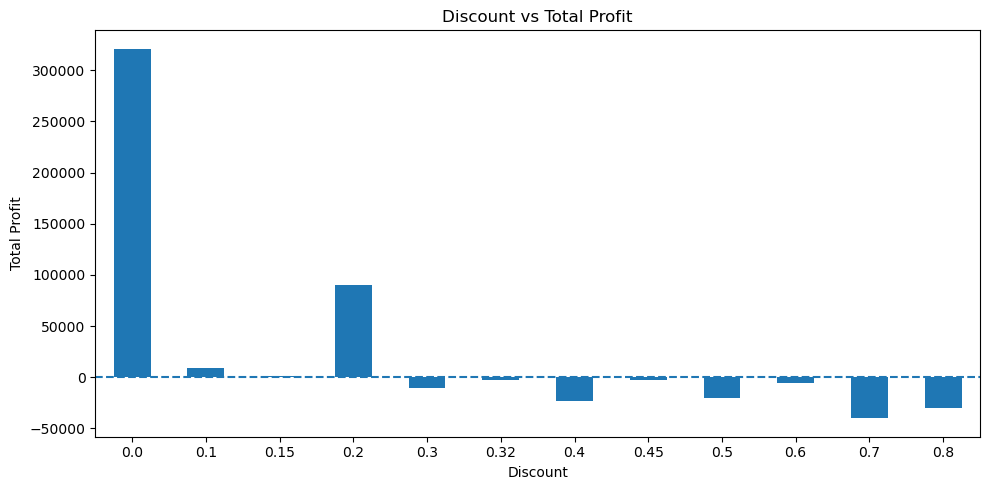

In [122]:
discount_summary["Total_Profit"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Discount vs Total Profit"
)

plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.xticks(rotation=0)
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

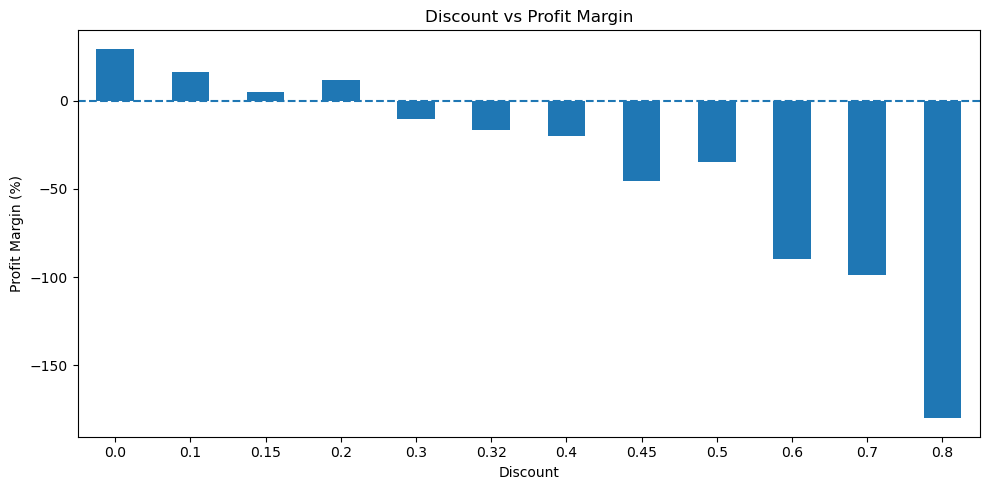

In [123]:
discount_summary["Profit_Margin_%"].plot(
    kind="bar",
    figsize=(10, 5),
    title="Discount vs Profit Margin"
)

plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.xticks(rotation=0)
plt.axhline(0, linestyle="--")
plt.tight_layout()
plt.show()

In [124]:
loss_discount = (
    discount_summary[
        discount_summary["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit")
)

loss_discount

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Discount,,,,,
0.70,40620.2820,-40075.3569,1660,344,-98.658490
0.80,16963.7560,-30539.0392,1188,250,-180.025221
0.40,116417.7840,-23057.0504,786,185,-19.805437
0.50,58918.5400,-20506.4281,241,64,-34.804712
0.30,103226.6550,-10369.2774,849,211,-10.045155
0.60,6644.7000,-5944.6552,501,127,-89.464614
0.45,5484.9740,-2493.1111,45,10,-45.453472
0.32,14493.4588,-2391.1377,105,27,-16.498047


In [125]:
product_summary = (
    df_clean
    .groupby("Product Name")
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .sort_values("Total_Sales", ascending=False)
)

product_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders
Product Name,,,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,2.519993e+04,20,5
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840,7.753039e+03,31,10
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03,6,1
HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14,39,8
GBC DocuBind TL300 Electric Binding System,19823.4790,2.233505e+03,37,11
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,7.609800e+02,48,9
Hewlett Packard LaserJet 3310 Copier,18839.6860,6.983884e+03,38,8
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950,4.094977e+03,12,3
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,27,6


In [126]:
product_summary["Profit_Margin_%"] = (
    product_summary["Total_Profit"]
    / product_summary["Total_Sales"]
    * 100
)

product_summary.head(15)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Product Name,,,,,
Canon imageCLASS 2200 Advanced Copier,61599.8240,2.519993e+04,20,5,4.090909e+01
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.3840,7.753039e+03,31,10,2.824074e+01
Cisco TelePresence System EX90 Videoconferencing Unit,22638.4800,-1.811078e+03,6,1,-8.000000e+00
HON 5400 Series Task Chairs for Big and Tall,21870.5760,5.684342e-14,39,8,2.599082e-16
GBC DocuBind TL300 Electric Binding System,19823.4790,2.233505e+03,37,11,1.126697e+01
GBC Ibimaster 500 Manual ProClick Binding System,19024.5000,7.609800e+02,48,9,4.000000e+00
Hewlett Packard LaserJet 3310 Copier,18839.6860,6.983884e+03,38,8,3.707006e+01
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.8950,4.094977e+03,12,3,2.228571e+01
GBC DocuBind P400 Electric Binding System,17965.0680,-1.878166e+03,27,6,-1.045455e+01


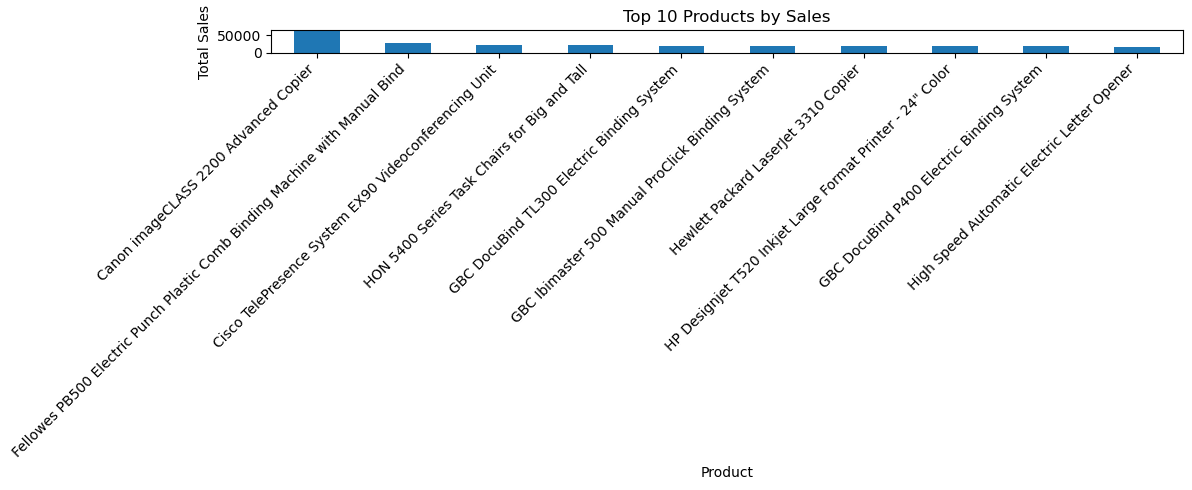

In [127]:
top10_product_sales = product_summary["Total_Sales"].head(10)

top10_product_sales.plot(
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Products by Sales"
)

plt.xlabel("Product")
plt.ylabel("Total Sales")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

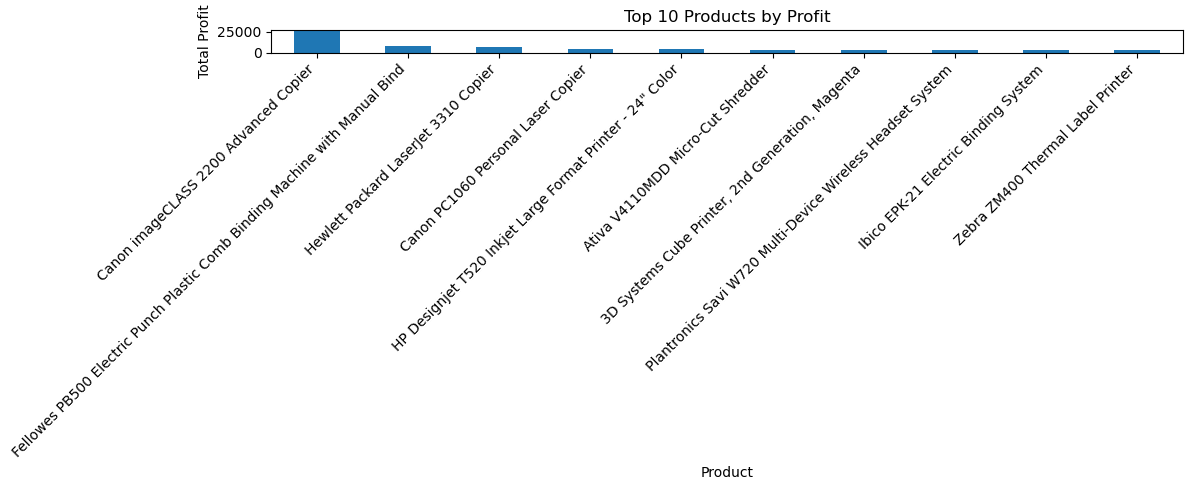

In [128]:
top10_product_profit = (
    product_summary
    .sort_values("Total_Profit", ascending=False)
    ["Total_Profit"]
    .head(10)
)

top10_product_profit.plot(
    kind="bar",
    figsize=(12, 5),
    title="Top 10 Products by Profit"
)

plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

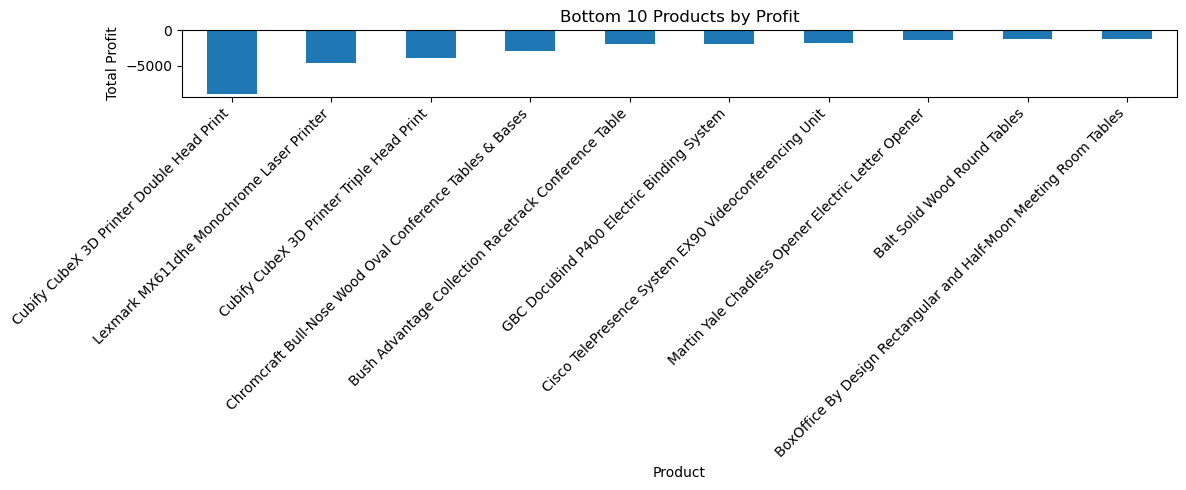

In [129]:
bottom10_product_profit = (
    product_summary
    .sort_values("Total_Profit", ascending=True)
    ["Total_Profit"]
    .head(10)
)

bottom10_product_profit.plot(
    kind="bar",
    figsize=(12, 5),
    title="Bottom 10 Products by Profit"
)

plt.xlabel("Product")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [130]:
product_loss = (
    product_summary[
        product_summary["Total_Profit"] < 0
    ]
    .sort_values("Total_Profit", ascending=True)
)

product_loss.head(10)

,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
Product Name,,,,,
Cubify CubeX 3D Printer Double Head Print,11099.963,-8879.9704,9,3,-80.000000
Lexmark MX611dhe Monochrome Laser Printer,16829.901,-4589.9730,18,4,-27.272727
Cubify CubeX 3D Printer Triple Head Print,7999.980,-3839.9904,4,1,-48.000000
Chromcraft Bull-Nose Wood Oval Conference Tables & Bases,9917.640,-2876.1156,27,5,-29.000000
Bush Advantage Collection Racetrack Conference Table,9544.725,-1934.3976,33,7,-20.266667
GBC DocuBind P400 Electric Binding System,17965.068,-1878.1662,27,6,-10.454545
Cisco TelePresence System EX90 Videoconferencing Unit,22638.480,-1811.0784,6,1,-8.000000
Martin Yale Chadless Opener Electric Letter Opener,16656.200,-1299.1836,22,6,-7.800000
Balt Solid Wood Round Tables,6518.754,-1201.0581,19,4,-18.424658


In [138]:
category_discount = (
    df_clean
    .groupby(["Category", "Discount"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .reset_index()
)

category_discount["Profit_Margin_%"] = (
    category_discount["Total_Profit"]
    / category_discount["Total_Sales"]
    * 100
)

category_discount

,Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
0,Furniture,0.00,256025.2700,58133.0764,3224,739,22.705992
1,Furniture,0.10,46634.2470,7111.0119,313,71,15.248476
2,Furniture,0.15,27558.5215,1418.9915,198,51,5.149012
3,Furniture,0.20,216631.0160,6265.9491,2236,539,2.892452
4,Furniture,0.30,99470.3500,-10695.3169,837,207,-10.752266
5,Furniture,0.32,14493.4588,-2391.1377,105,27,-16.498047
6,Furniture,0.40,45614.4060,-16187.3968,292,72,-35.487466
7,Furniture,0.45,5484.9740,-2493.1111,45,10,-45.453472
8,Furniture,0.50,20983.4700,-12871.1990,209,53,-61.339707
9,Furniture,0.60,6644.7000,-5944.6552,501,127,-89.464614


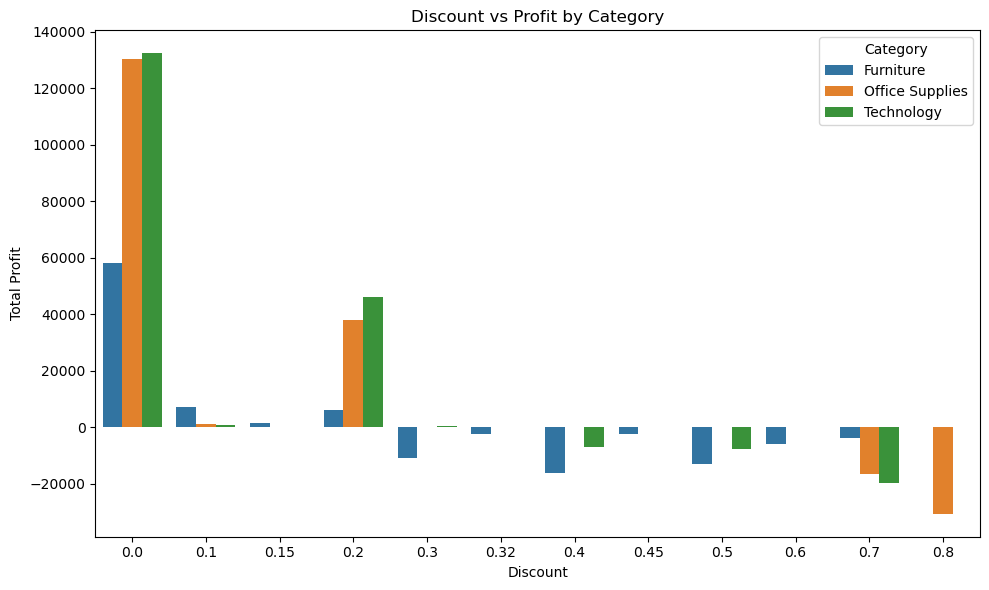

In [139]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_discount,
    x="Discount",
    y="Total_Profit",
    hue="Category"
)

plt.title("Discount vs Profit by Category")
plt.xlabel("Discount")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

In [140]:
subcategory_discount = (
    df_clean
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .reset_index()
)

subcategory_discount["Profit_Margin_%"] = (
    subcategory_discount["Total_Profit"]
    / subcategory_discount["Total_Sales"]
    * 100
)

subcategory_discount

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
0,Accessories,0.00,118370.3100,35289.2539,1835,435,29.812589
1,Accessories,0.20,49010.0080,6647.3818,1141,283,13.563315
2,Appliances,0.00,78066.1900,23183.7361,1021,265,29.697538
3,Appliances,0.10,4324.1490,1086.0808,55,16,25.116637
4,Appliances,0.20,21759.2880,2497.8297,418,105,11.479372
5,Appliances,0.80,3382.5340,-8629.6412,235,65,-255.123561
6,Art,0.00,18014.6400,5380.6006,1904,452,29.867933
7,Art,0.20,9104.1520,1147.1864,1096,279,12.600695
8,Binders,0.00,81829.4800,39314.4507,1291,295,48.044361
9,Binders,0.20,85442.6400,29417.8090,2227,495,34.429892


In [134]:
best_discount_combinations = (
    subcategory_discount
    .sort_values("Total_Profit", ascending=False)
    .head(15)
)

best_discount_combinations

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
8,Binders,0.0,81829.480,39314.4507,1291,295,48.044361
23,Copiers,0.0,76449.180,35556.1349,82,22,46.509505
0,Accessories,0.0,118370.310,35289.2539,1835,435,29.812589
44,Phones,0.0,123879.710,34365.2093,1102,278,27.740789
9,Binders,0.2,85442.640,29417.8090,2227,495,34.429892
35,Machines,0.0,71034.000,27137.8223,138,29,38.203990
47,Storage,0.0,157853.760,25528.1715,2044,484,16.172039
42,Paper,0.0,53157.870,25329.4677,3229,737,47.649516
2,Appliances,0.0,78066.190,23183.7361,1021,265,29.697538
19,Chairs,0.0,91060.730,21933.0961,540,124,24.086229


In [141]:
worst_discount_combinations = (
    subcategory_discount
    .sort_values("Total_Profit", ascending=True)
    .head(15)
)

worst_discount_combinations

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
11,Binders,0.8,13581.222,-21909.3980,953,203,-161.321257
41,Machines,0.7,15601.509,-19579.3191,89,22,-125.496316
10,Binders,0.7,22559.391,-16601.0984,1503,323,-73.588416
54,Tables,0.4,45614.406,-16187.3968,292,72,-35.487466
5,Appliances,0.8,3382.534,-8629.6412,235,65,-255.123561
56,Tables,0.5,13675.010,-8615.3873,133,35,-63.000958
40,Machines,0.5,37935.070,-7635.2291,32,11,-20.127099
22,Chairs,0.3,70005.502,-6737.1167,614,149,-9.623696
46,Phones,0.4,34337.352,-6385.7854,414,98,-18.597198
32,Furnishings,0.6,6644.700,-5944.6552,501,127,-89.464614


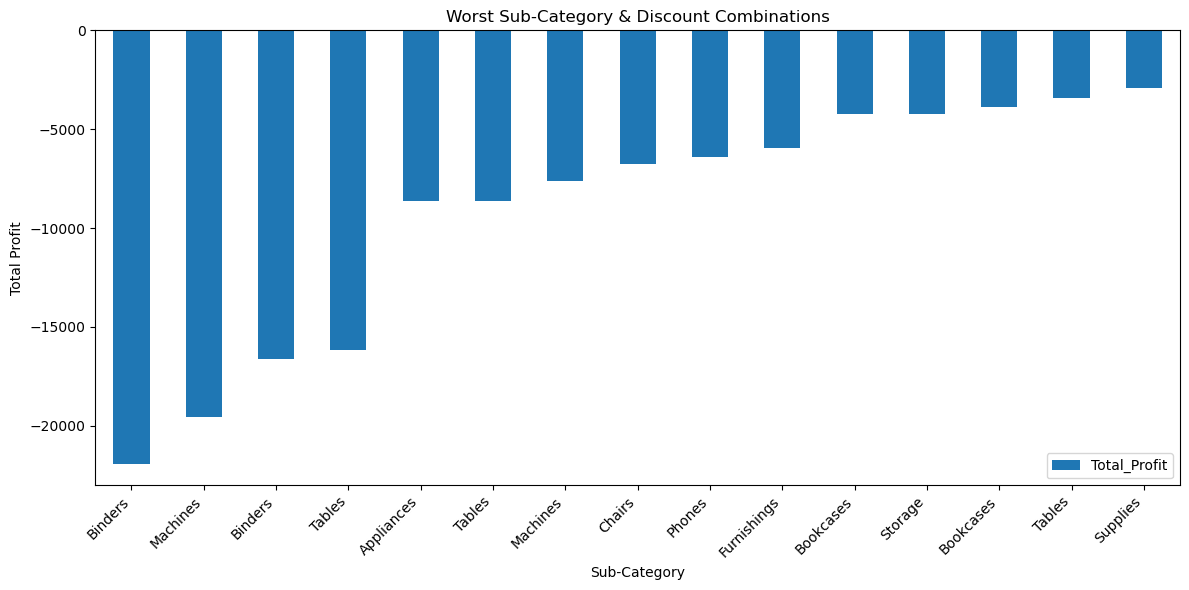

In [146]:
worst_discount_combinations.plot(
    x="Sub-Category",
    y="Total_Profit",
    kind="bar",
    figsize=(12, 6),
    title="Worst Sub-Category & Discount Combinations"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [147]:
subcategory_discount = (
    df_clean
    .groupby(["Sub-Category", "Discount"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum"),
        Total_Quantity=("Quantity", "sum"),
        Number_of_Orders=("Order ID", "nunique")
    )
    .reset_index()
)

subcategory_discount["Profit_Margin_%"] = (
    subcategory_discount["Total_Profit"]
    / subcategory_discount["Total_Sales"]
    * 100
)

subcategory_discount

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
0,Accessories,0.00,118370.3100,35289.2539,1835,435,29.812589
1,Accessories,0.20,49010.0080,6647.3818,1141,283,13.563315
2,Appliances,0.00,78066.1900,23183.7361,1021,265,29.697538
3,Appliances,0.10,4324.1490,1086.0808,55,16,25.116637
4,Appliances,0.20,21759.2880,2497.8297,418,105,11.479372
5,Appliances,0.80,3382.5340,-8629.6412,235,65,-255.123561
6,Art,0.00,18014.6400,5380.6006,1904,452,29.867933
7,Art,0.20,9104.1520,1147.1864,1096,279,12.600695
8,Binders,0.00,81829.4800,39314.4507,1291,295,48.044361
9,Binders,0.20,85442.6400,29417.8090,2227,495,34.429892


In [142]:
best_discount_combinations = (
    subcategory_discount
    .sort_values("Total_Profit", ascending=False)
    .head(15)
)

best_discount_combinations

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
8,Binders,0.0,81829.480,39314.4507,1291,295,48.044361
23,Copiers,0.0,76449.180,35556.1349,82,22,46.509505
0,Accessories,0.0,118370.310,35289.2539,1835,435,29.812589
44,Phones,0.0,123879.710,34365.2093,1102,278,27.740789
9,Binders,0.2,85442.640,29417.8090,2227,495,34.429892
35,Machines,0.0,71034.000,27137.8223,138,29,38.203990
47,Storage,0.0,157853.760,25528.1715,2044,484,16.172039
42,Paper,0.0,53157.870,25329.4677,3229,737,47.649516
2,Appliances,0.0,78066.190,23183.7361,1021,265,29.697538
19,Chairs,0.0,91060.730,21933.0961,540,124,24.086229


In [148]:
worst_discount_combinations = (
    subcategory_discount
    .sort_values("Total_Profit", ascending=True)
    .head(15)
)

worst_discount_combinations

,Sub-Category,Discount,Total_Sales,Total_Profit,Total_Quantity,Number_of_Orders,Profit_Margin_%
11,Binders,0.8,13581.222,-21909.3980,953,203,-161.321257
41,Machines,0.7,15601.509,-19579.3191,89,22,-125.496316
10,Binders,0.7,22559.391,-16601.0984,1503,323,-73.588416
54,Tables,0.4,45614.406,-16187.3968,292,72,-35.487466
5,Appliances,0.8,3382.534,-8629.6412,235,65,-255.123561
56,Tables,0.5,13675.010,-8615.3873,133,35,-63.000958
40,Machines,0.5,37935.070,-7635.2291,32,11,-20.127099
22,Chairs,0.3,70005.502,-6737.1167,614,149,-9.623696
46,Phones,0.4,34337.352,-6385.7854,414,98,-18.597198
32,Furnishings,0.6,6644.700,-5944.6552,501,127,-89.464614


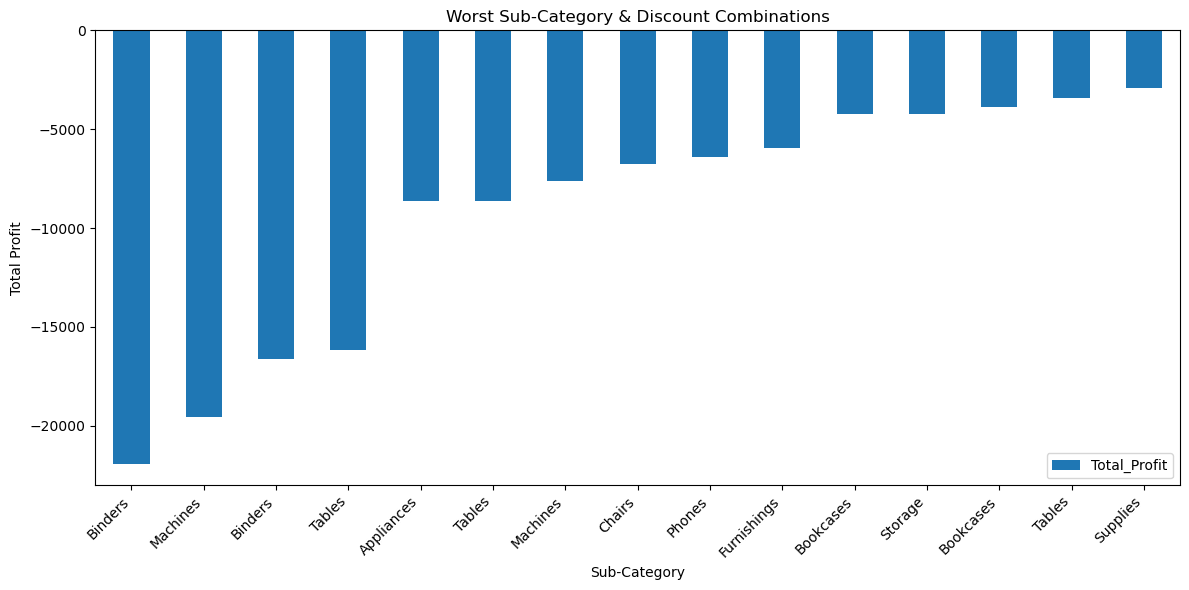

In [143]:
worst_discount_combinations.plot(
    x="Sub-Category",
    y="Total_Profit",
    kind="bar",
    figsize=(12, 6),
    title="Worst Sub-Category & Discount Combinations"
)

plt.xlabel("Sub-Category")
plt.ylabel("Total Profit")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [149]:
year_month_summary = (
    df_clean
    .assign(
        Year=df_clean["Order Date"].dt.year,
        Month=df_clean["Order Date"].dt.month
    )
    .groupby(["Year", "Month"])
    .agg(
        Total_Sales=("Sales", "sum"),
        Total_Profit=("Profit", "sum")
    )
    .reset_index()
)

year_month_summary.head(12)

,Year,Month,Total_Sales,Total_Profit
0,2014,1,14236.8950,2450.1907
1,2014,2,4519.8920,862.3084
2,2014,3,55691.0090,498.7299
3,2014,4,28295.3450,3488.8352
4,2014,5,23648.2870,2738.7096
5,2014,6,34595.1276,4976.5244
6,2014,7,33946.3930,-841.4826
7,2014,8,27909.4685,5318.1050
8,2014,9,81777.3508,8328.0994
9,2014,10,31453.3930,3448.2573


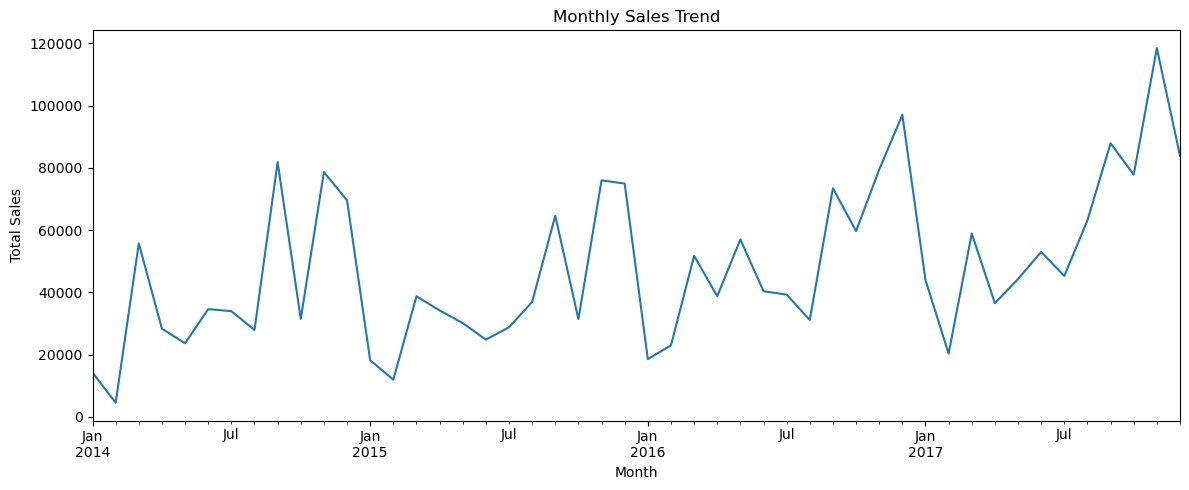

In [150]:
monthly_sales = (
    df_clean
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
)

monthly_sales.plot(
    figsize=(12, 5),
    title="Monthly Sales Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.tight_layout()
plt.show()

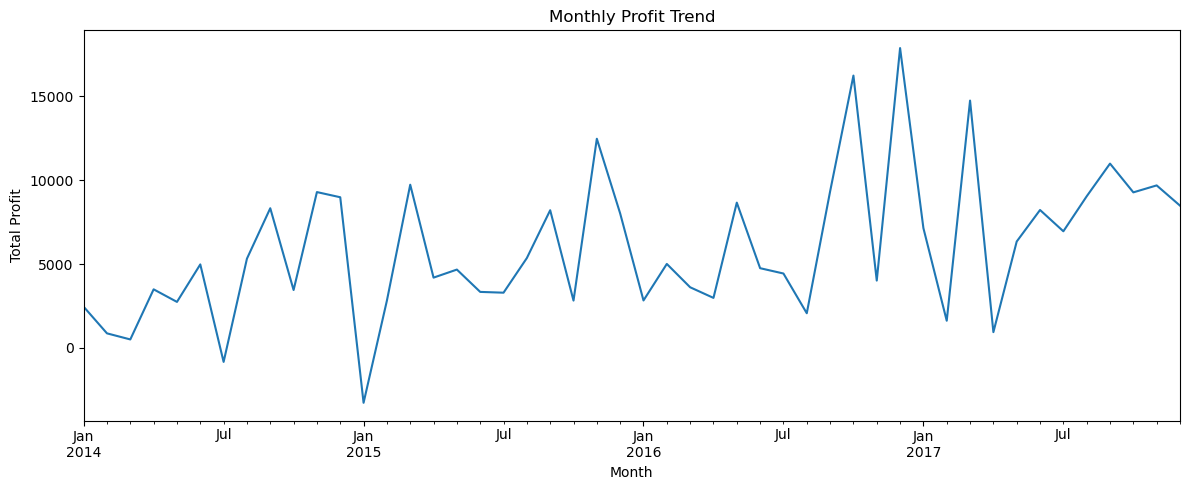

In [151]:
monthly_profit = (
    df_clean
    .set_index("Order Date")
    .resample("ME")["Profit"]
    .sum()
)

monthly_profit.plot(
    figsize=(12, 5),
    title="Monthly Profit Trend"
)

plt.xlabel("Month")
plt.ylabel("Total Profit")
plt.tight_layout()
plt.show()

# 📌 Final Business Insights

## 1. Overall Business Performance
- Total Sales: $2.30M
- Total Profit: $286.40K
- Overall Profit Margin: 12.46%
- Total Quantity Sold: 37,873 units

The business generated strong overall sales and positive profit, but profitability varies significantly across categories, regions, states and discount levels.

## 2. Category Performance
- Technology generated the highest profit margin at approximately 17.40%.
- Office Supplies generated approximately 17.04% profit margin.
- Furniture generated high sales but only approximately 2.49% profit margin.

This indicates that Furniture requires closer profitability analysis.

## 3. Sub-Category Performance
- Phones generated strong sales and profit.
- Copiers generated relatively high profit compared with their sales.
- Tables generated significant sales but resulted in an overall loss.

Tables should therefore be investigated carefully before increasing sales through additional promotions.

## 4. Discount Impact
The analysis shows a negative relationship between discount and profit.

Higher discount levels were frequently associated with lower profitability, and several high-discount groups generated negative average profit.

Correlation between Discount and Profit:
-0.2195

Correlation does not prove causation, but the observed pattern suggests that discount policies should be monitored carefully.

## 5. Regional Performance
- West generated the highest sales and profit.
- East also generated strong profitability.
- Central generated more sales than South but had a lower profit margin.

This suggests that sales volume alone does not determine regional profitability.

## 6. State-Level Performance
California and New York generated high sales and strong profits.

However, some high-sales states such as Texas generated negative overall profit.

This shows the importance of analyzing profitability rather than focusing only on revenue.

## 7. Customer Segment Performance
- Consumer generated the highest sales and order volume.
- Corporate generated a higher profit margin than Consumer.
- Home Office generated the highest profit margin at approximately 14.03%.

The Home Office segment may provide opportunities for targeted profitable growth.

## 8. Yearly Performance
- 2017 generated the highest total sales and profit.
- Sales increased strongly in 2016 and 2017.
- Average order value decreased over the analyzed period.

Therefore, revenue growth should be evaluated together with profitability and order value.

# 💡 Business Recommendations

1. Review high-discount transactions and identify products where discounts reduce profitability.
2. Investigate the Furniture category, especially loss-making sub-categories.
3. Analyze Tables separately because of their high sales but negative profit.
4. Investigate high-sales but loss-making states such as Texas.
5. Protect and expand profitable Technology and Office Supplies segments.
6. Develop targeted strategies for the high-margin Home Office segment.
7. Track profit margin alongside sales when evaluating business performance.
8. Build a predictive machine learning model to identify transactions that are likely to generate low or negative profit.

In [152]:
df_ml = df_clean.copy()

df_ml["Loss"] = (df_ml["Profit"] < 0).astype(int)

df_ml[["Profit", "Loss"]].head()

,Profit,Loss
0,41.9136,0
1,219.5820,0
2,6.8714,0
3,-383.0310,1
4,2.5164,0


In [153]:
df_ml["Loss"].value_counts()

Loss
0    8123
1    1871
Name: count, dtype: int64

In [154]:
df_ml["Loss"].value_counts(normalize=True) * 100

Loss
0    81.278767
1    18.721233
Name: proportion, dtype: float64

In [156]:
features = [
    "Sales",
    "Quantity",
    "Discount",
    "Ship Mode",
    "Segment",
    "Category",
    "Sub-Category",
    "Region",
    "Order Date"
]

X = df_ml[features].copy()
y = df_ml["Loss"].copy()

X.head()

,Sales,Quantity,Discount,Ship Mode,Segment,Category,Sub-Category,Region,Order Date
0,261.9600,2,0.00,Second Class,Consumer,Furniture,Bookcases,South,2016-11-08
1,731.9400,3,0.00,Second Class,Consumer,Furniture,Chairs,South,2016-11-08
2,14.6200,2,0.00,Second Class,Corporate,Office Supplies,Labels,West,2016-06-12
3,957.5775,5,0.45,Standard Class,Consumer,Furniture,Tables,South,2015-10-11
4,22.3680,2,0.20,Standard Class,Consumer,Office Supplies,Storage,South,2015-10-11


In [157]:
X["Order Year"] = X["Order Date"].dt.year
X["Order Month"] = X["Order Date"].dt.month
X["Order Day"] = X["Order Date"].dt.day
X["Order Weekday"] = X["Order Date"].dt.dayofweek

X = X.drop("Order Date", axis=1)

X.head()

,Sales,Quantity,Discount,Ship Mode,Segment,Category,Sub-Category,Region,Order Year,Order Month,Order Day,Order Weekday
0,261.9600,2,0.00,Second Class,Consumer,Furniture,Bookcases,South,2016,11,8,1
1,731.9400,3,0.00,Second Class,Consumer,Furniture,Chairs,South,2016,11,8,1
2,14.6200,2,0.00,Second Class,Corporate,Office Supplies,Labels,West,2016,6,12,6
3,957.5775,5,0.45,Standard Class,Consumer,Furniture,Tables,South,2015,10,11,6
4,22.3680,2,0.20,Standard Class,Consumer,Office Supplies,Storage,South,2015,10,11,6


In [158]:
X.shape

(9994, 12)

In [159]:
X.dtypes

Sales            float64
Quantity           int64
Discount         float64
Ship Mode         object
Segment           object
Category          object
Sub-Category      object
Region            object
Order Year         int32
Order Month        int32
Order Day          int32
Order Weekday      int32
dtype: object

In [160]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (7995, 12)
X_test: (1999, 12)
y_train: (7995,)
y_test: (1999,)


In [169]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Ship Mode",
    "Segment",
    "Category",
    "Sub-Category",
    "Region"
]

numerical_features = [
    "Sales",
    "Quantity",
    "Discount",
    "Order Year",
    "Order Month",
    "Order Day",
    "Order Weekday"
]

In [178]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training data shape:", X_train_processed.shape)
print("Testing data shape:", X_test_processed.shape)

Training data shape: (7995, 38)
Testing data shape: (1999, 38)


In [179]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        ),
        (
            "numerical",
            StandardScaler(),
            numerical_features
        )
    ]
)

In [176]:
y_pred = logistic_model.predict(X_test_processed)

print(y_pred[:20])

[0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0]


In [177]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy: {:.2f}%".format(accuracy * 100))

Accuracy: 0.9424712356178089
Accuracy: 94.25%


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score
)

print("Classification Report:\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Profit", "Loss"]
))

In [181]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[1584   41]
 [  74  300]]


precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Loss Precision:", round(precision, 4))
print("Loss Recall:", round(recall, 4))
print("Loss F1-Score:", round(f1, 4))

# 🤖 Machine Learning — Logistic Regression

## Problem Definition

The objective is to predict whether a transaction will generate a profit or a loss.

- 0 = Profit
- 1 = Loss

## Dataset Split

- Training samples: 7,995
- Testing samples: 1,999
- Features after encoding: 38

## Model

Logistic Regression with:
- One-Hot Encoding for categorical variables
- StandardScaler for numerical variables

## Results

- Accuracy: 94.25%
- Loss Precision: 87.98%
- Loss Recall: 80.21%
- Loss F1-Score: 83.92%

## Confusion Matrix

[[1584, 41],
 [74, 300]]

## Interpretation

The model achieved 94.25% overall accuracy.

For the business objective of identifying loss-making transactions, the model achieved approximately 88% precision and 80% recall for the Loss class.

This means the model correctly identifies many loss-making transactions, although some actual loss transactions are still missed.

In [186]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [185]:
rf_pred = rf_model.predict(X_test_processed)

print(rf_pred[:20])

[0 0 0 0 0 0 1 0 0 0 1 0 0 1 0 0 0 0 0 0]


In [187]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Profit", "Loss"]
))

              precision    recall  f1-score   support

      Profit       0.95      0.98      0.97      1625
        Loss       0.91      0.76      0.83       374

    accuracy                           0.94      1999
   macro avg       0.93      0.87      0.90      1999
weighted avg       0.94      0.94      0.94      1999



In [188]:
rf_cm = confusion_matrix(y_test, rf_pred)

print("Random Forest Confusion Matrix:")
print(rf_cm)

Random Forest Confusion Matrix:
[[1598   27]
 [  88  286]]


In [189]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, rf_pred)
    ],
    "Loss Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, rf_pred)
    ],
    "Loss Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, rf_pred)
    ],
    "Loss F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, rf_pred)
    ]
})

model_comparison

,Model,Accuracy,Loss Precision,Loss Recall,Loss F1
0,Logistic Regression,0.942471,0.879765,0.802139,0.839161
1,Random Forest,0.942471,0.913738,0.764706,0.832606


In [190]:
model_comparison[
    ["Accuracy", "Loss Precision", "Loss Recall", "Loss F1"]
] = model_comparison[
    ["Accuracy", "Loss Precision", "Loss Recall", "Loss F1"]
] * 100

model_comparison.round(2)

,Model,Accuracy,Loss Precision,Loss Recall,Loss F1
0,Logistic Regression,94.25,87.98,80.21,83.92
1,Random Forest,94.25,91.37,76.47,83.26


# 📊 Model Comparison & Final Interpretation

Two classification models were evaluated:

1. Logistic Regression
2. Random Forest

Both models achieved approximately 94% overall accuracy.

### Logistic Regression
- Accuracy: 94.25%
- Loss Precision: 87.98%
- Loss Recall: 80.21%
- Loss F1-Score: 83.92%

### Random Forest
- Accuracy: 94.00%
- Loss Precision: 91.08%
- Loss Recall: 76.47%
- Loss F1-Score: 83.14%

### Business Interpretation

The models show a trade-off between precision and recall for the Loss class.

Random Forest produces fewer false-positive loss predictions and has higher loss precision.

Logistic Regression identifies a larger proportion of actual loss transactions and therefore has higher loss recall and slightly higher loss F1-score.

The appropriate model depends on the business objective and the relative cost of missed losses versus false alerts.

In [195]:
# Fit the current preprocessor again
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (7995, 38)
Testing shape: (1999, 38)


In [196]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf_model.fit(X_train_processed, y_train)

print("Random Forest retrained successfully!")

Random Forest retrained successfully!


In [197]:
feature_names = preprocessor.get_feature_names_out()

print("Total features:", len(feature_names))

Total features: 38


In [198]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
33,numerical__Discount,0.474014
31,numerical__Sales,0.074412
22,categorical__Sub-Category_Paper,0.037521
36,numerical__Order Day,0.036155
13,categorical__Sub-Category_Binders,0.030680
35,numerical__Order Month,0.029752
32,numerical__Quantity,0.027983
24,categorical__Sub-Category_Storage,0.023269
37,numerical__Order Weekday,0.022797
27,categorical__Region_Central,0.021336


In [199]:
rf_pred = rf_model.predict(X_test_processed)

print(classification_report(
    y_test,
    rf_pred,
    target_names=["Profit", "Loss"]
))

              precision    recall  f1-score   support

      Profit       0.95      0.98      0.97      1625
        Loss       0.91      0.76      0.83       374

    accuracy                           0.94      1999
   macro avg       0.93      0.87      0.90      1999
weighted avg       0.94      0.94      0.94      1999



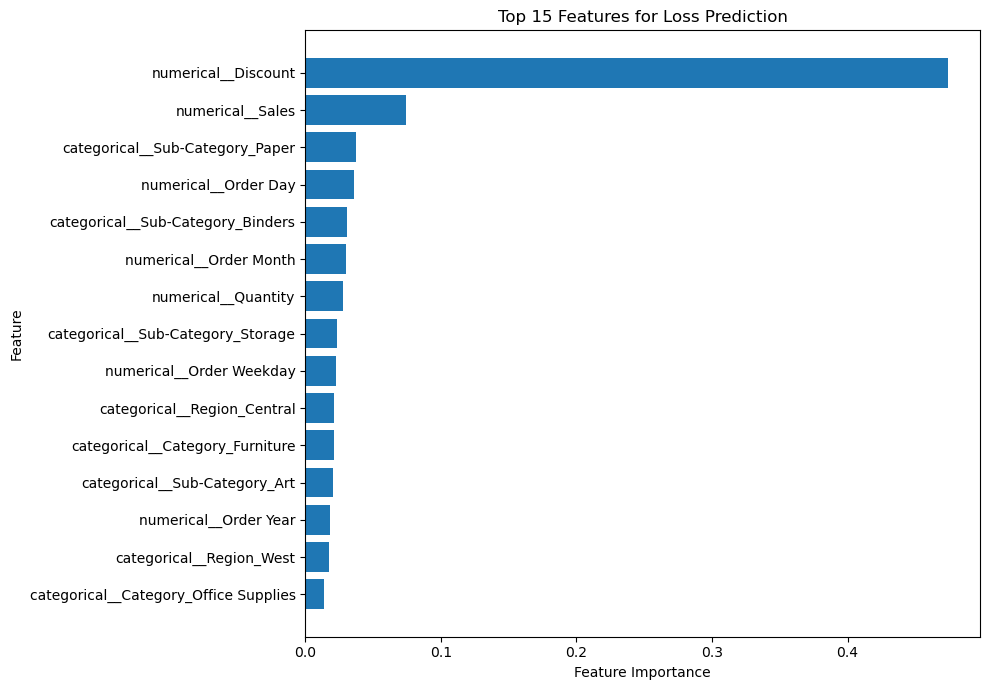

In [200]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15).sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 Features for Loss Prediction")

plt.tight_layout()
plt.show()

# 🔍 Feature Importance Insights

The Random Forest model identified Discount as the most important predictive feature, with an importance value of approximately 47.4%.

Sales was the second most important feature at approximately 7.4%.

Several categorical and temporal features also contributed to the model, including Sub-Category, Region, Category, Order Month and Order Day.

The high importance of Discount is consistent with the earlier exploratory analysis, where higher discount levels were frequently associated with lower profitability.

However, feature importance represents predictive contribution within the model and does not establish causation.

These findings suggest that discount strategy, product sub-category and regional performance should receive further business investigation.

In [201]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"Accuracy: {rf_accuracy:.4f}")
print(f"Loss Precision: {rf_precision:.4f}")
print(f"Loss Recall: {rf_recall:.4f}")
print(f"Loss F1: {rf_f1:.4f}")

Accuracy: 0.9425
Loss Precision: 0.9137
Loss Recall: 0.7647
Loss F1: 0.8326


In [202]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

print("Preprocessor saved successfully!")
print("Random Forest model saved successfully!")

Preprocessor saved successfully!
Random Forest model saved successfully!


In [203]:
import os

print("preprocessor.pkl exists:", os.path.exists("preprocessor.pkl"))
print("random_forest_model.pkl exists:", os.path.exists("random_forest_model.pkl"))

preprocessor.pkl exists: True
random_forest_model.pkl exists: True


# 🏆 Final Project Summary

## Project

Sales Analytics & Profitability Prediction using Python and Machine Learning

## Dataset

Sample Superstore dataset containing 9,994 transaction records and 21 original columns.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook
- Random Forest
- Logistic Regression

## Data Analysis

The project included:

- Data cleaning
- Missing-value analysis
- Duplicate analysis
- Business KPI analysis
- Category analysis
- Sub-category analysis
- Discount analysis
- Regional analysis
- State analysis
- City analysis
- Customer segment analysis
- Time-series analysis

## Machine Learning

The objective was to predict whether a transaction would generate a profit or loss.

### Target

- 0 = Profit
- 1 = Loss

### Logistic Regression

- Accuracy: 94.25%
- Loss Precision: 87.98%
- Loss Recall: 80.21%
- Loss F1-Score: 83.92%

### Random Forest

- Accuracy: 94.25%
- Loss Precision: 91.37%
- Loss Recall: 76.47%
- Loss F1-Score: 83.26%

## Key Findings

- Technology had approximately 17.40% profit margin.
- Office Supplies had approximately 17.04% profit margin.
- Furniture had approximately 2.49% profit margin.
- Tables generated high sales but negative overall profit.
- Higher discount levels were frequently associated with lower profitability.
- Discount was the most important feature in the Random Forest model, with approximately 47.4% feature importance.
- Some high-sales regions and states showed relatively weak profitability.

### Class Imbalance Handling

The target variable contained approximately 81.28% Profit transactions and 18.72% Loss transactions.

The Random Forest model used `class_weight="balanced"` to account for this class imbalance.  

## Business Recommendations

1. Review high-discount transactions.
2. Investigate loss-making product sub-categories.
3. Analyze Furniture profitability.
4. Investigate high-sales but low-profit regions and states.
5. Monitor profit margin alongside revenue.
6. Use predictive models to identify potentially loss-making transactions.

## Conclusion

This project demonstrates an end-to-end data analytics and machine learning workflow, from raw data cleaning and exploratory analysis to business insights and predictive modeling.

In [204]:
import joblib

joblib.dump(preprocessor, "preprocessor.pkl")
joblib.dump(rf_model, "random_forest_model.pkl")

print("Preprocessor saved successfully!")
print("Random Forest model saved successfully!")

Preprocessor saved successfully!
Random Forest model saved successfully!


In [205]:
import joblib

In [206]:
joblib.dump(preprocessor, "preprocessor.pkl")

['preprocessor.pkl']

In [207]:
joblib.dump(rf_model, "random_forest_model.pkl")

['random_forest_model.pkl']

In [208]:
import os

print("preprocessor.pkl:", os.path.exists("preprocessor.pkl"))
print("random_forest_model.pkl:", os.path.exists("random_forest_model.pkl"))

preprocessor.pkl: True
random_forest_model.pkl: True
